## 第三章 特征工程


In [1]:
## 输出高清图像
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
## 图像显示中文的问题
import matplotlib
matplotlib.rcParams['axes.unicode_minus']=False

import seaborn as sns 
sns.set(font= "Kaiti",style="ticks",font_scale=1.4)

In [2]:
## 导入会使用到的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import preprocessing
from scipy.stats import boxcox
import re
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

### 3.1 数据预处理

#### 3.1.1 无量纲化处理

数据标准化、缩放、归一化

In [3]:
## 使用鸢尾花数据来演示
Iris = pd.read_csv("data/chap3/Iris.csv")
Iris2 = Iris.drop(["Id","Species"],axis = 1)
print(Iris2.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2


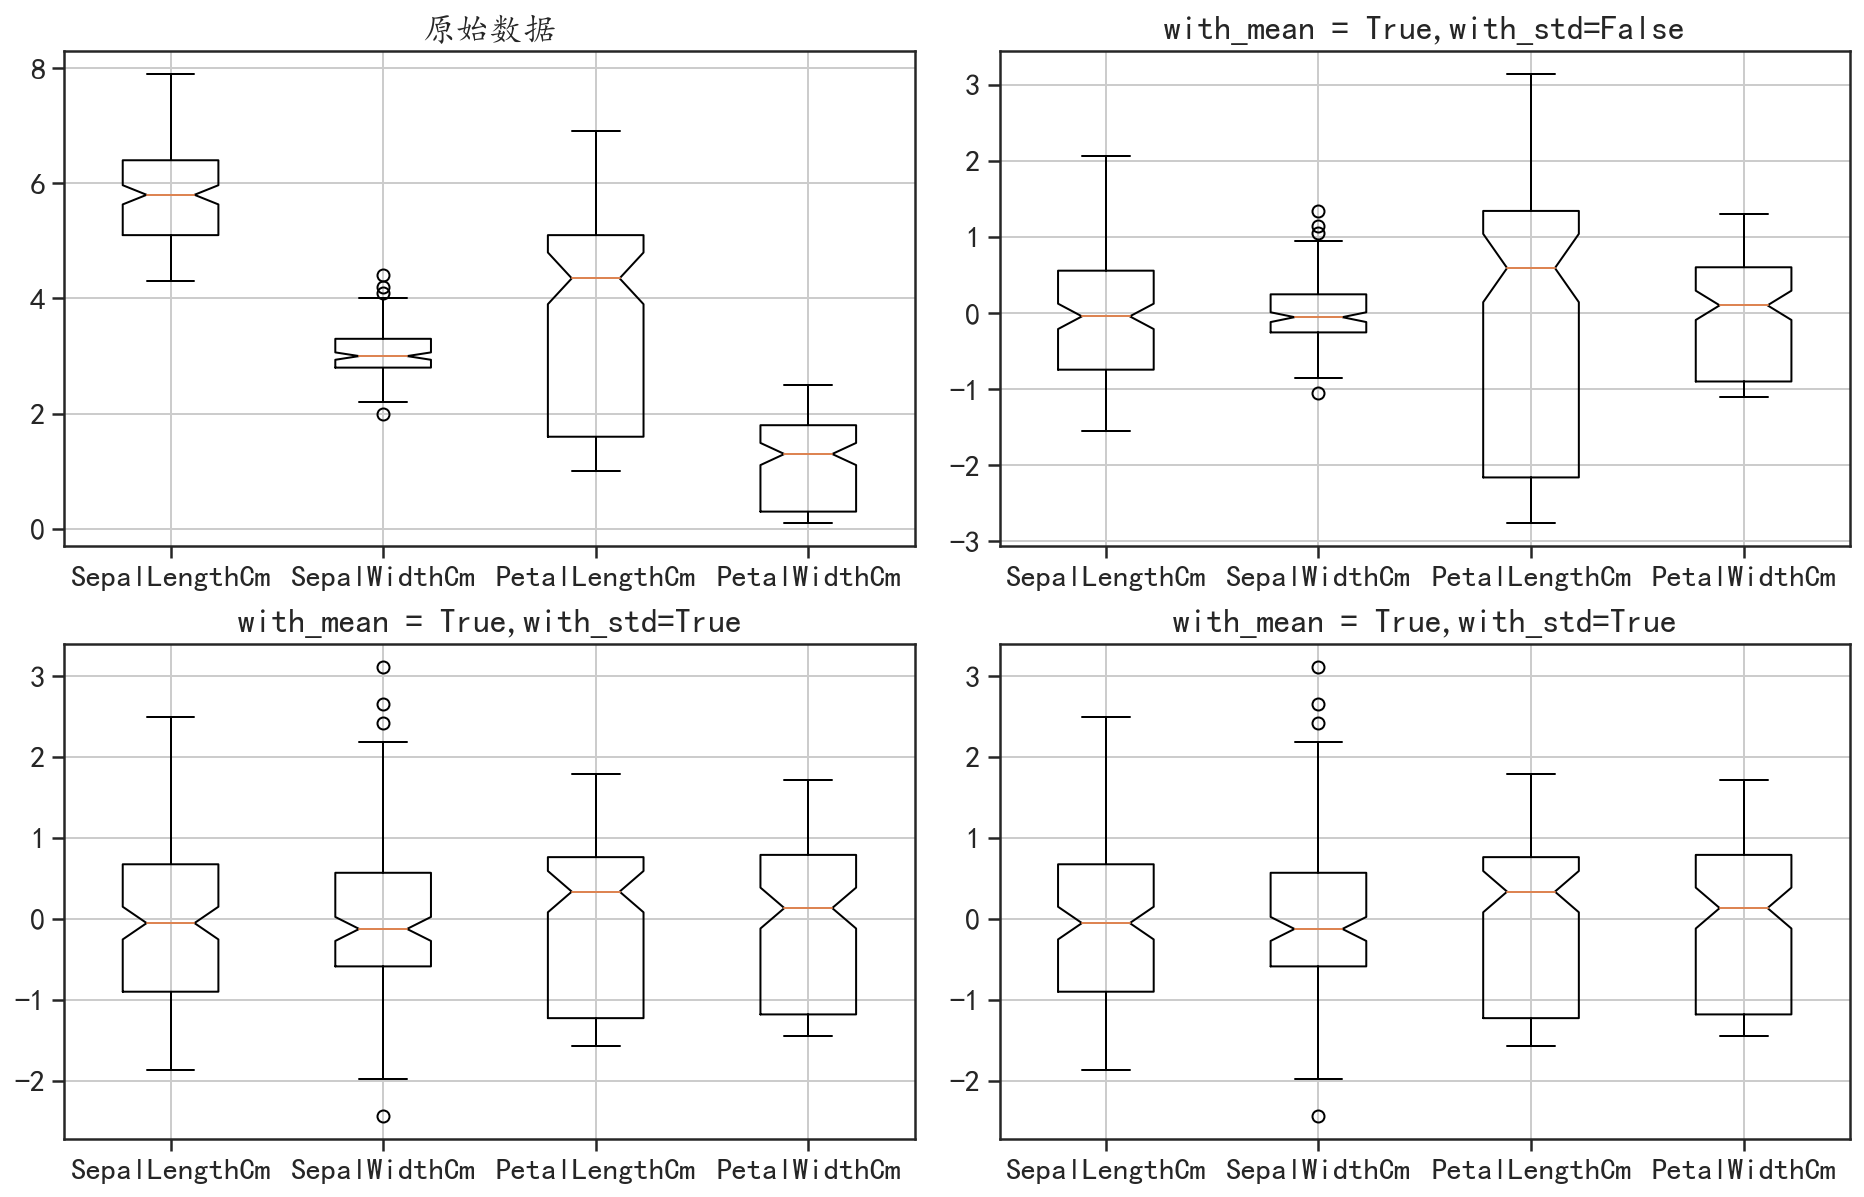

In [4]:
## 将4个数值变量进行标准化，并可视化标准化前后的数据变化情况
## 只减去均值
data_scale1 = preprocessing.scale(Iris2,with_mean = True,with_std=False)
## 减去均值后除以标准差
data_scale2 = preprocessing.scale(Iris2,with_mean = True,with_std=True)
## 另一种减去均值后除以标准差的方式
data_scale3 = preprocessing.StandardScaler(with_mean = True,with_std=True).fit_transform(Iris2)
## 将获得的结果使用箱线图进行可视化分析


## 可视化原始数据和变换后的数据分布
labs = Iris2.columns.values
plt.figure(figsize = (16,10))
plt.subplot(2,2,1)
plt.boxplot(Iris2.values,notch=True,labels = labs)
plt.grid()
plt.title("原始数据")
plt.subplot(2,2,2)
plt.boxplot(data_scale1,notch=True,labels = labs)
plt.grid()
plt.title("with_mean = True,with_std=False")
plt.subplot(2,2,3)
plt.boxplot(data_scale2,notch=True,labels = labs)
plt.grid()
plt.title("with_mean = True,with_std=True")
plt.subplot(2,2,4)
plt.boxplot(data_scale3,notch=True,labels = labs)
plt.grid()
plt.title("with_mean = True,with_std=True")
plt.subplots_adjust(wspace = 0.1)
plt.show()

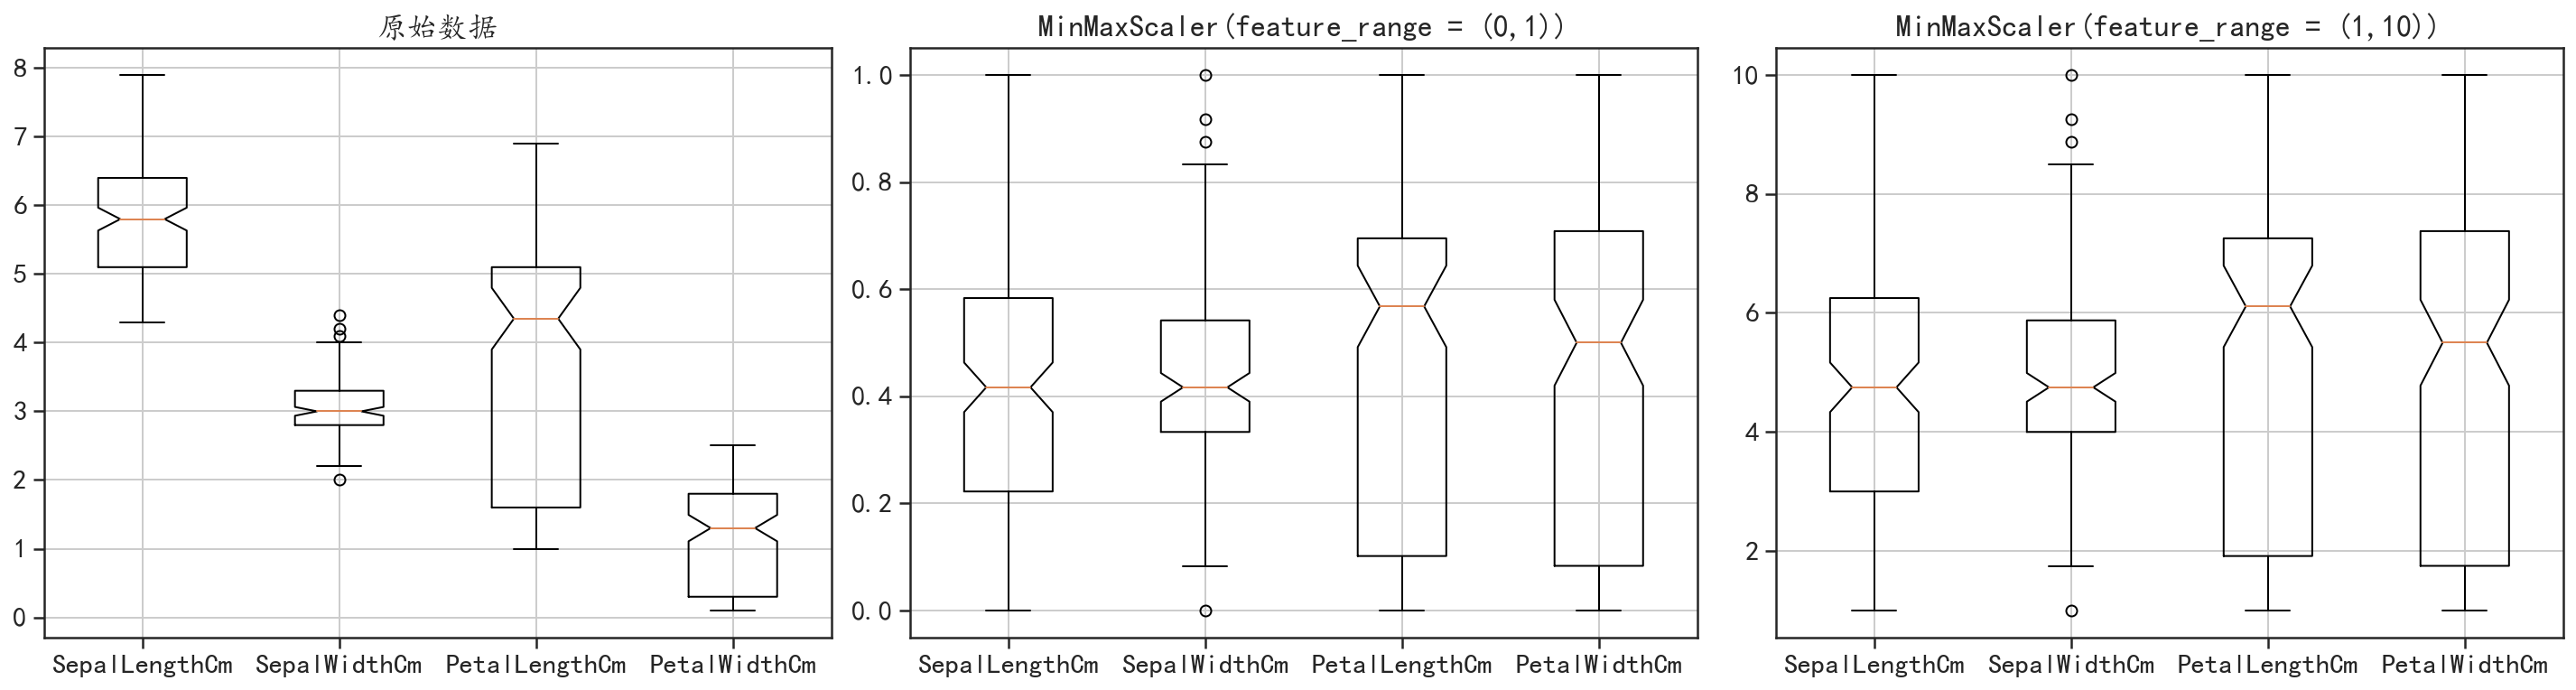

In [5]:
## 将数据说缩放到指定的区间
data_minmax1 = preprocessing.MinMaxScaler(feature_range = (0,1)).fit_transform(Iris2)
data_minmax2 = preprocessing.MinMaxScaler(feature_range = (1,10)).fit_transform(Iris2)

## 可视化数据缩放后的结果
labs = Iris2.columns.values
plt.figure(figsize = (25,6))
plt.subplot(1,3,1)
plt.boxplot(Iris2.values,notch=True,labels = labs)
plt.grid()
plt.title("原始数据")
plt.subplot(1,3,2)
plt.boxplot(data_minmax1,notch=True,labels = labs)
plt.grid()
plt.title("MinMaxScaler(feature_range = (0,1))")
plt.subplot(1,3,3)
plt.boxplot(data_minmax2,notch=True,labels = labs)
plt.grid()
plt.title("MinMaxScaler(feature_range = (1,10))")
plt.subplots_adjust(wspace = 0.1)
plt.show()

##  数据的分布趋势是不变的，但是数据的取值范围发生了改变

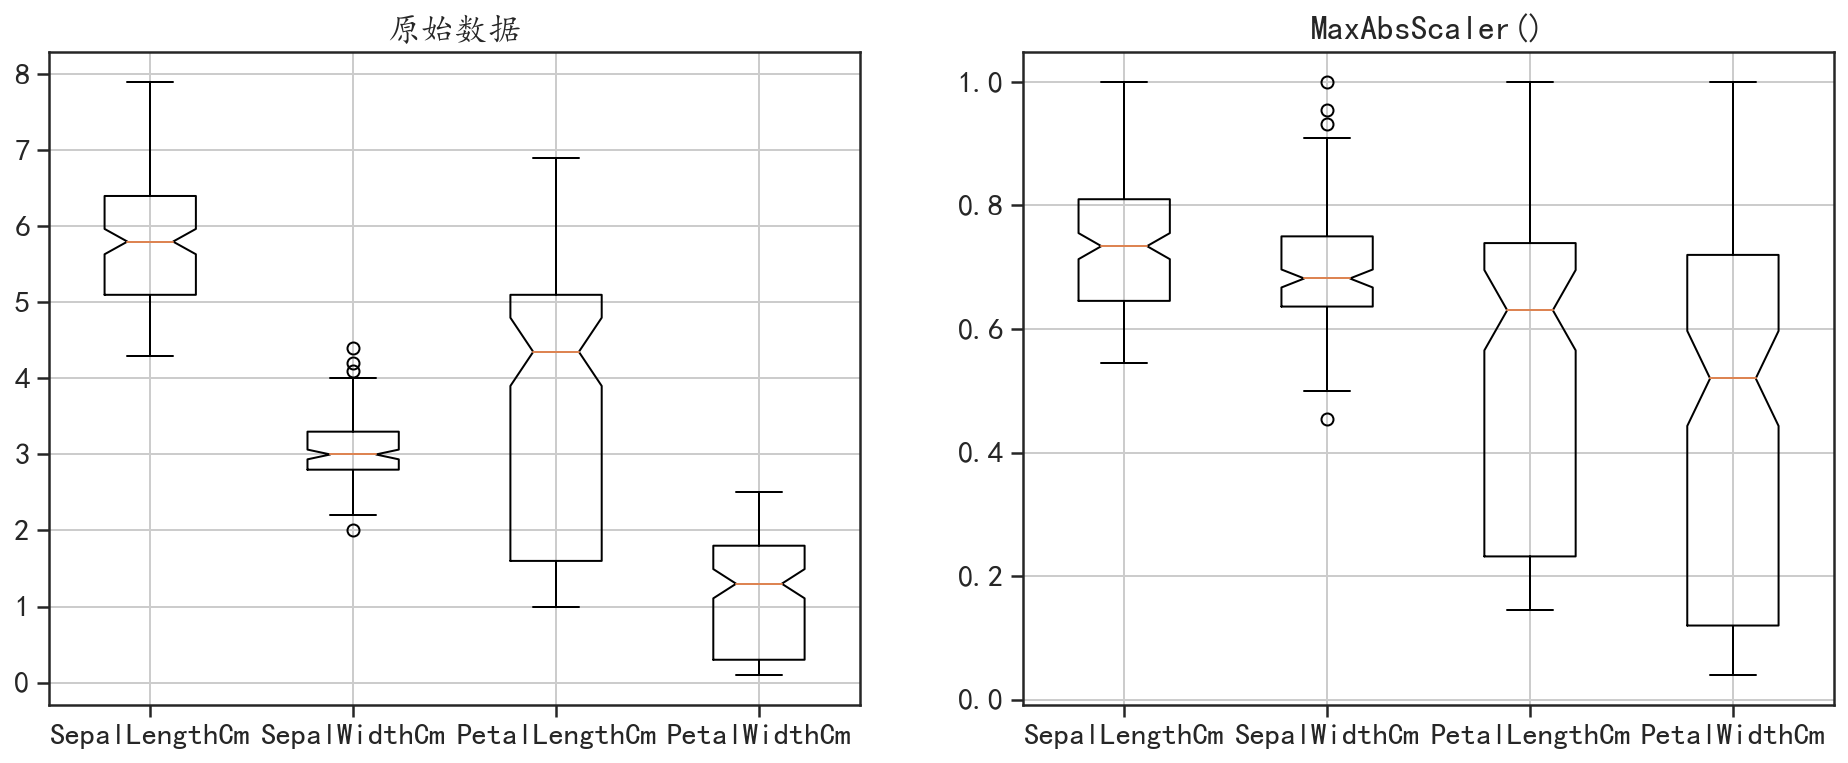

In [6]:
## 通过最大绝对值缩放每个特征
data_maxabs = preprocessing.MaxAbsScaler().fit_transform(Iris2)

## 使训练集中每个特征的最大绝对值为1.0

## 可视化数据缩放后的结果
labs = Iris2.columns.values
plt.figure(figsize = (16,6))
plt.subplot(1,2,1)
plt.boxplot(Iris2.values,notch=True,labels = labs)
plt.grid()
plt.title("原始数据")
plt.subplot(1,2,2)
plt.boxplot(data_maxabs,notch=True,labels = labs)
plt.grid()
plt.title("MaxAbsScaler()")
plt.show()


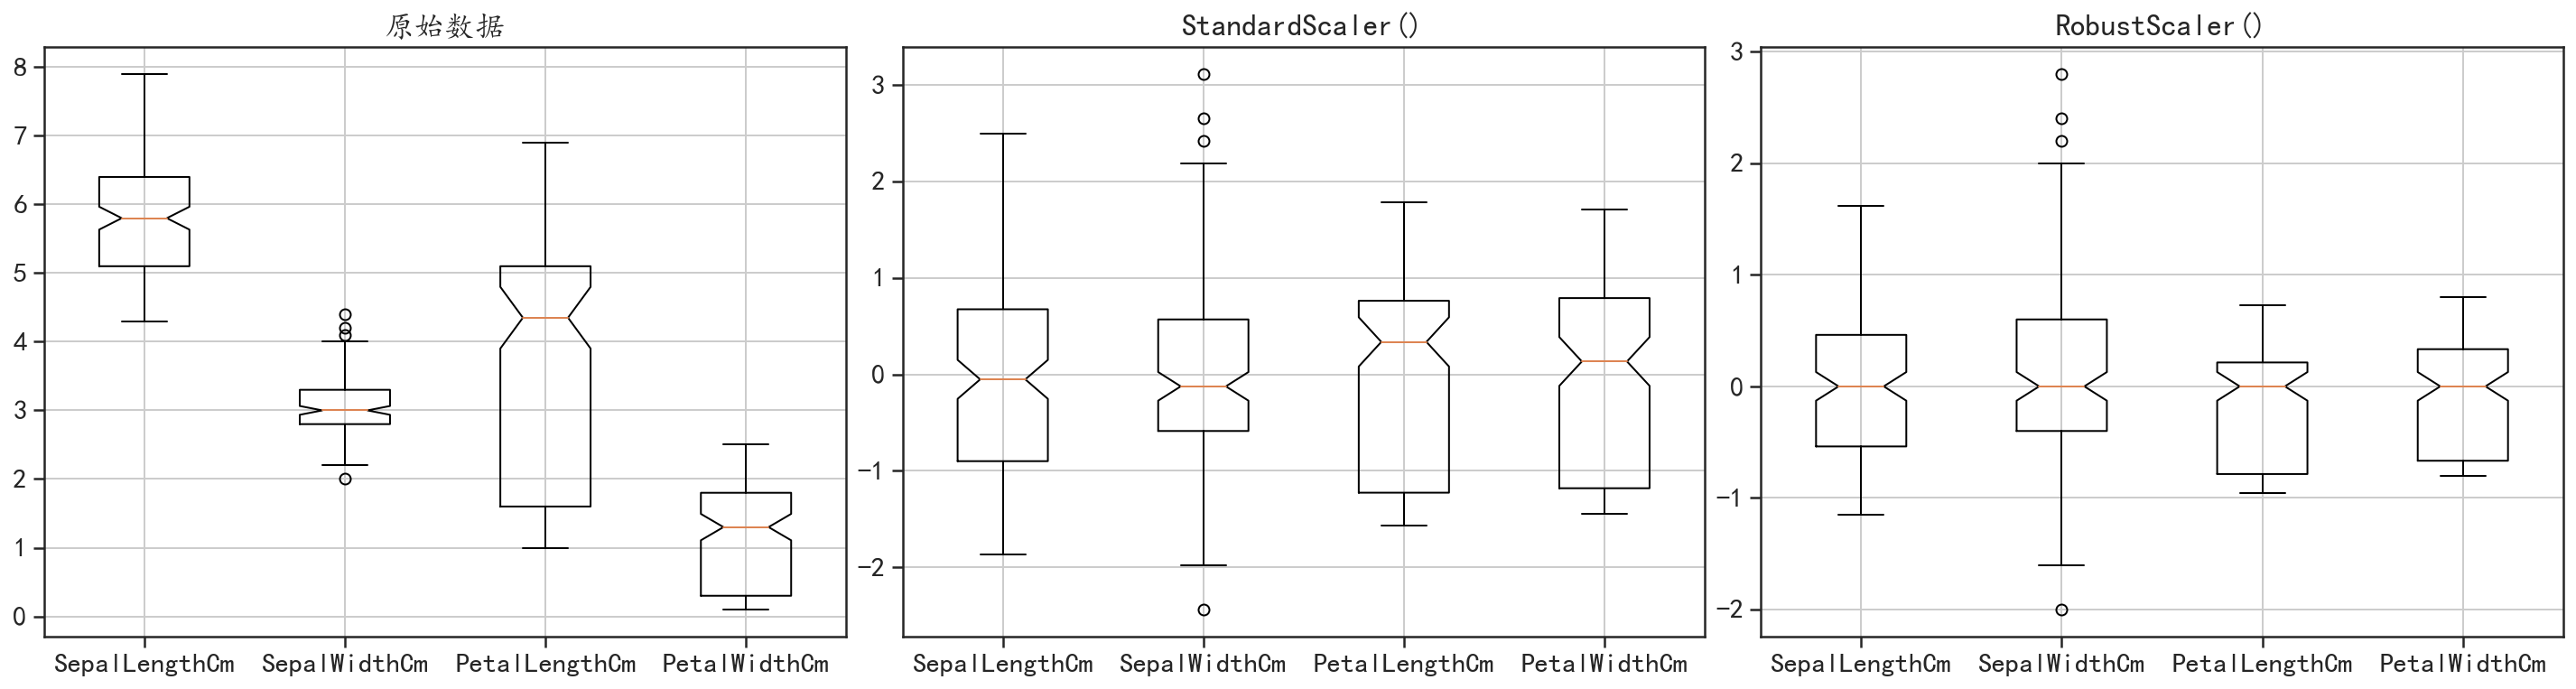

In [7]:
## 对带有异常值的数据进行标准化
data_robs = preprocessing.RobustScaler(with_centering = True,with_scaling=True).fit_transform(Iris2)

## 可视化数据缩放后的结果
labs = Iris2.columns.values
plt.figure(figsize = (25,6))
plt.subplot(1,3,1)
plt.boxplot(Iris2.values,notch=True,labels = labs)
plt.grid()
plt.title("原始数据")
plt.subplot(1,3,2)
plt.boxplot(data_scale2,notch=True,labels = labs)
plt.grid()
plt.title("StandardScaler()")
plt.subplot(1,3,3)
plt.boxplot(data_robs,notch=True,labels = labs)
plt.grid()
plt.title("RobustScaler()")
plt.subplots_adjust(wspace = 0.07)
plt.show()


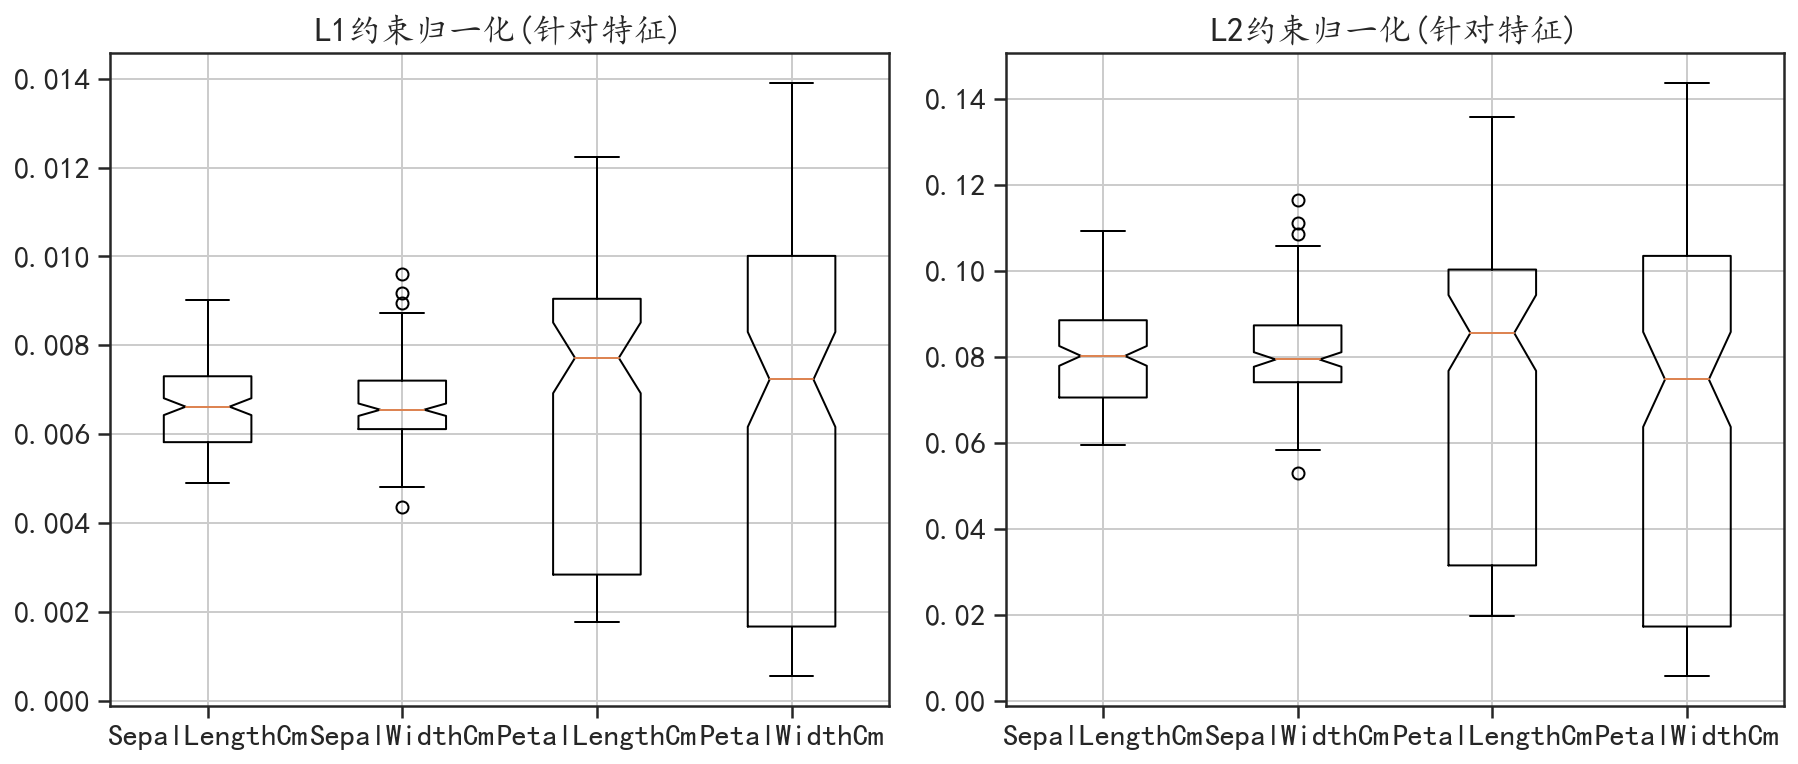

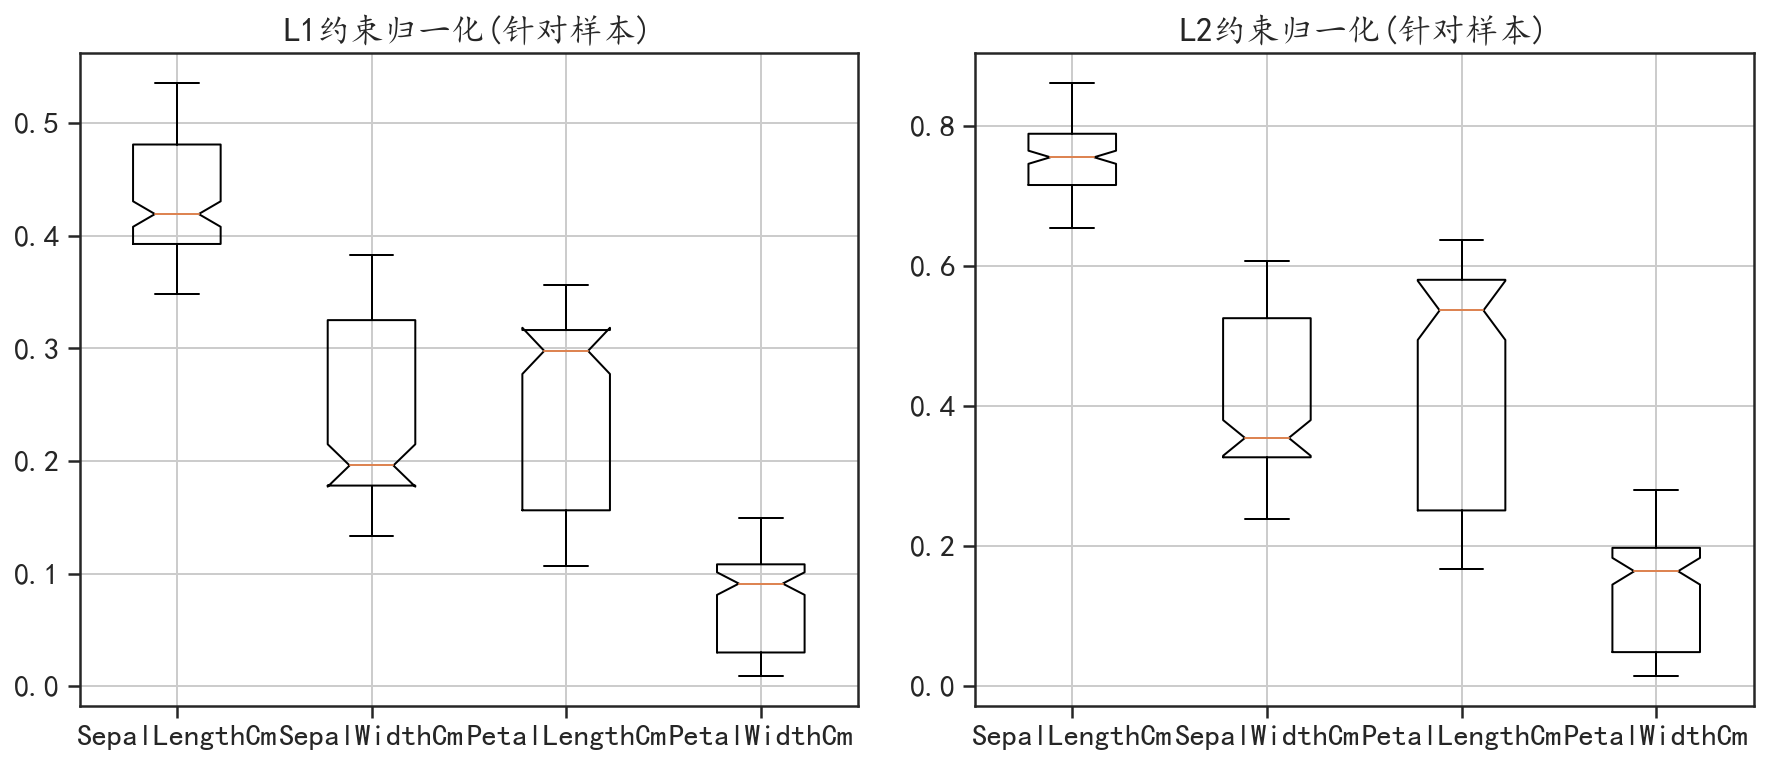

In [8]:
## 正则化归一化，axis = 0表示针对特征进行操作
data_normL1 = preprocessing.normalize(Iris2,norm = "l1",axis = 0)
data_normL2 = preprocessing.normalize(Iris2,norm = "l2",axis = 0)


## 可视化数据缩放后的结果
labs = Iris2.columns.values
plt.figure(figsize = (15,6))
plt.subplot(1,2,1)
plt.boxplot(data_normL1,notch=True,labels = labs)
plt.grid()
plt.title("L1约束归一化(针对特征)")
plt.subplot(1,2,2)
plt.boxplot(data_normL2,notch=True,labels = labs)
plt.grid()
plt.title("L2约束归一化(针对特征)")
plt.subplots_adjust(wspace = 0.15)
plt.show()



## 正则化归一化，axis = 1表示针对每个样本进行操作
data_normL1 = preprocessing.normalize(Iris2,norm = "l1",axis = 1)
data_normL2 = preprocessing.normalize(Iris2,norm = "l2",axis = 1)


## 可视化数据缩放后的结果
labs = Iris2.columns.values
plt.figure(figsize = (15,6))
plt.subplot(1,2,1)
plt.boxplot(data_normL1,notch=True,labels = labs)
plt.grid()
plt.title("L1约束归一化(针对样本)")
plt.subplot(1,2,2)
plt.boxplot(data_normL2,notch=True,labels = labs)
plt.grid()
plt.title("L2约束归一化(针对样本)")
plt.subplots_adjust(wspace = 0.15)
plt.show()


#### 3.1.2 数据变换


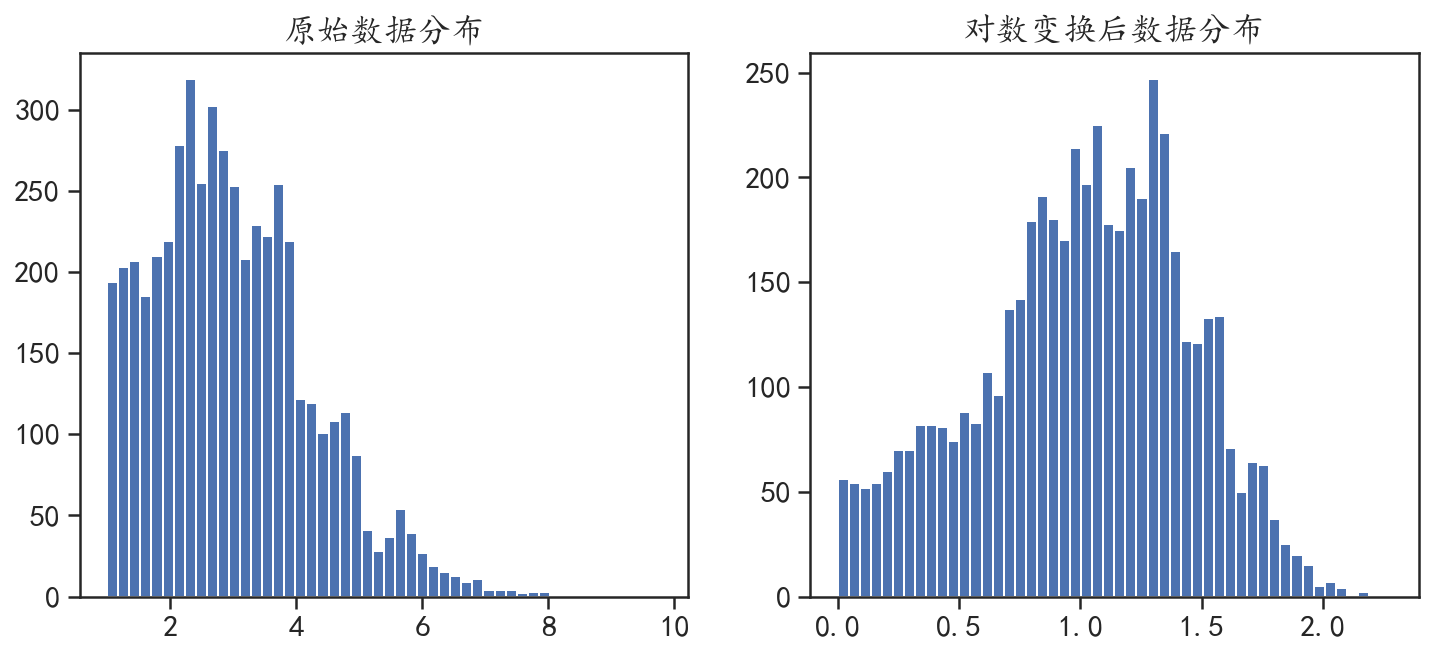

In [9]:
## 通过变换改变数据的分布等性质

## 对数变换
np.random.seed(12)
x = 1+np.random.poisson(lam = 1.5,size = 5000)+np.random.rand(5000)
## 对x进行对数变换
lnx = np.log(x)
## 可视化变换前后的数据分布
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(x,bins = 50)
plt.title("原始数据分布")
plt.subplot(1,2,2)
plt.hist(lnx,bins = 50)
plt.title("对数变换后数据分布")
plt.show()


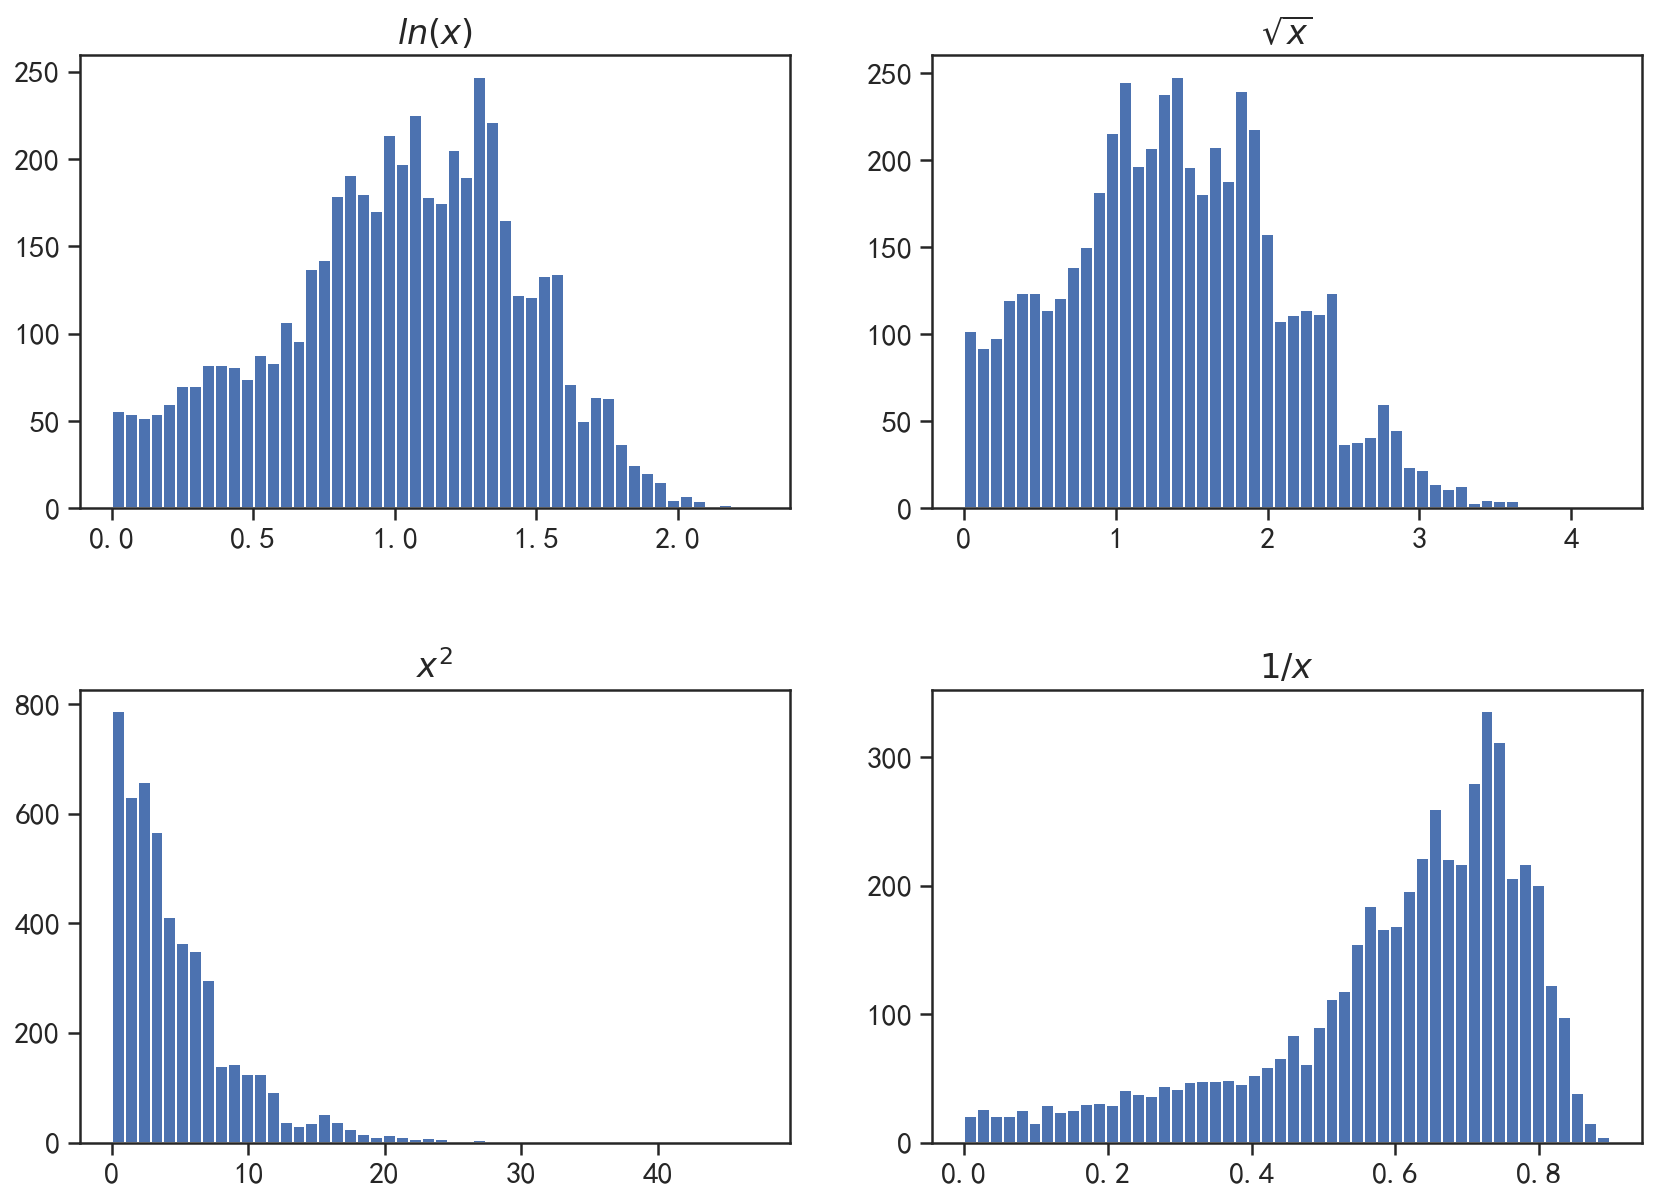

In [10]:
## box-cox 变换 ：自动寻找最佳正态分布变换函数的方法
from scipy.stats import boxcox
np.random.seed(12)
x = 1+np.random.poisson(lam = 1.5,size = 5000)+np.random.rand(5000)
## 对x进行对数变换
bcx1 = boxcox(x,lmbda = 0)
bcx2 = boxcox(x,lmbda = 0.5)
bcx3 = boxcox(x,lmbda = 2)
bcx4 = boxcox(x,lmbda = -1)
## 可视化变换后的数据分布
plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
plt.hist(bcx1,bins = 50)
plt.title("$ln(x)$")
plt.subplot(2,2,2)
plt.hist(bcx2,bins = 50)
plt.title("$\sqrt{x}$")
plt.subplot(2,2,3)
plt.hist(bcx3,bins = 50)
plt.title("$x^2$")
plt.subplot(2,2,4)
plt.hist(bcx4,bins = 50)
plt.title("$ 1/x $")
plt.subplots_adjust(hspace = 0.4)
plt.show()


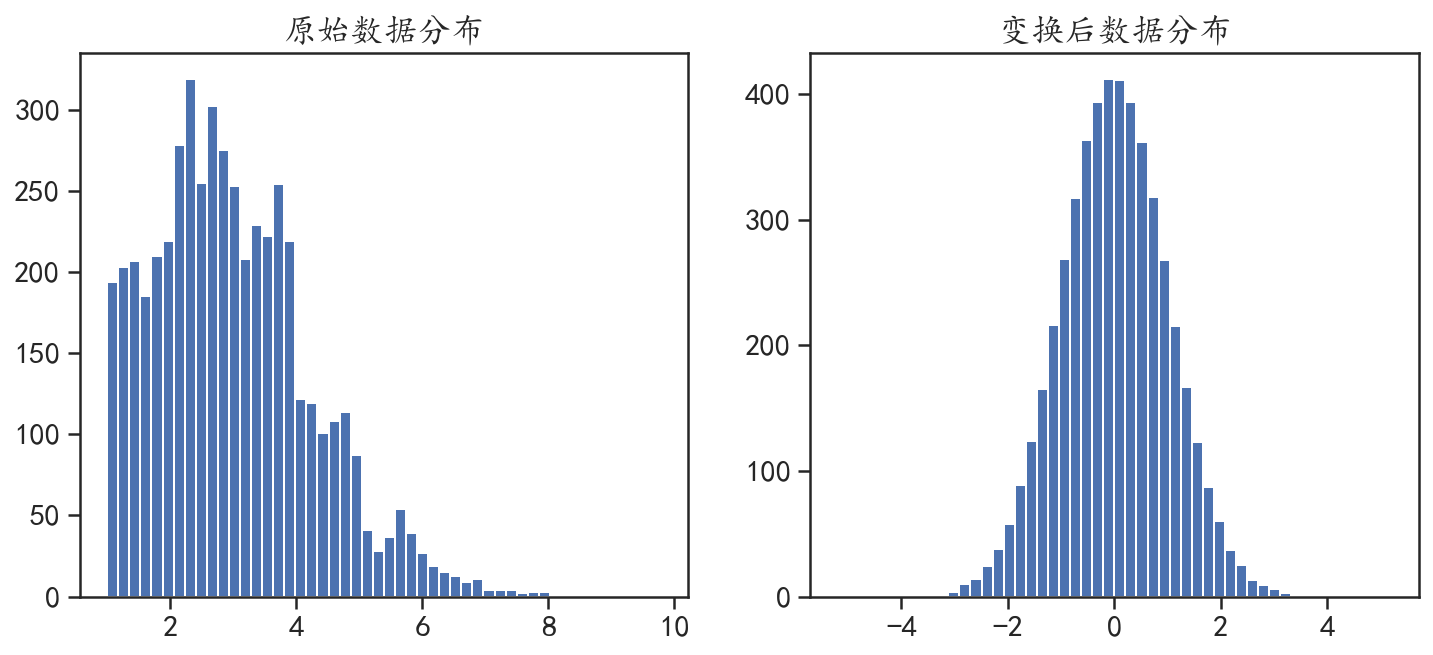

In [11]:
## 使用分为数信息进行数据特征变换

## 定义将数据变换为正太分布的方法
QTn = preprocessing.QuantileTransformer(output_distribution = "normal",random_state=0)
## 对x进行对数变换,x要转化为二维数组
QTnx = QTn.fit_transform(x.reshape(5000,1))
## 可视化变换前后的数据分布
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(x,bins = 50)
plt.title("原始数据分布")
plt.subplot(1,2,2)
plt.hist(QTnx,bins = 50)
plt.title("变换后数据分布")
plt.show()


### 3.2 特征构建

#### 分类特征重新编码

In [12]:
## 准备类别标签数据
np.random.seed(12)
label = np.random.choice(Iris.Species.values,size = 4,replace = False)
label = label.reshape(-1,1)
print("label:",label)

## 分类特征编码为常数
OrdE = preprocessing.OrdinalEncoder()
label_OrdE = OrdE.fit_transform(label)
print("分类特征编码为常数:\n",label_OrdE)

label: [['Iris-setosa']
 ['Iris-virginica']
 ['Iris-setosa']
 ['Iris-versicolor']]
分类特征编码为常数:
 [[0.]
 [2.]
 [0.]
 [1.]]


In [13]:
## 分类特征编码为0～n-1的整数
le = preprocessing.LabelEncoder()
label_le = le.fit_transform([1,2,3,10,10])
print("编码为0～n-1的整数:",label_le)

编码为0～n-1的整数: [0 1 2 3 3]


In [14]:
## One-Hot编码
OneHotE = preprocessing.OneHotEncoder()
label_OneHotE = OneHotE.fit_transform(label)
print("One-Hot编码:\n",label_OneHotE.toarray())

One-Hot编码:
 [[1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [15]:
## 以one vs all 的方式对标签进行二值化
LB = preprocessing.LabelBinarizer()
label_LB = OneHotE.fit_transform(label)
print("one vs all的方式对标签二值化:\n",label_LB.toarray())

one vs all的方式对标签二值化:
 [[1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [16]:
## 对多标签类别进行编码
mlb = preprocessing.MultiLabelBinarizer()
label_mlb = mlb.fit_transform([("A", "B"), ("B","C"), ("D")])
print("多标签类别编码:\n",label_mlb)

多标签类别编码:
 [[1 1 0 0]
 [0 1 1 0]
 [0 0 0 1]]


#### 数值特征重新编码

In [17]:
## 生成新的特征，针对单个变量多项式特征
X = np.arange(1,5).reshape(-1,1)
polyF = preprocessing.PolynomialFeatures(degree=3,include_bias=False)
polyFX = polyF.fit_transform(X)
polyFX

array([[ 1.,  1.,  1.],
       [ 2.,  4.,  8.],
       [ 3.,  9., 27.],
       [ 4., 16., 64.]])

In [18]:
## 生成新的特征，针对多个变量多项式特征
X2 = np.arange(1,11).reshape(-1,2)
polyFm = preprocessing.PolynomialFeatures(degree=2,interaction_only=False,include_bias=False)
polyFXm = polyFm.fit_transform(X2)
polyFXm

## X2 = [a,b]
## polyFX = [a,b,a^2,a*b,b^2]

array([[  1.,   2.,   1.,   2.,   4.],
       [  3.,   4.,   9.,  12.,  16.],
       [  5.,   6.,  25.,  30.,  36.],
       [  7.,   8.,  49.,  56.,  64.],
       [  9.,  10.,  81.,  90., 100.]])

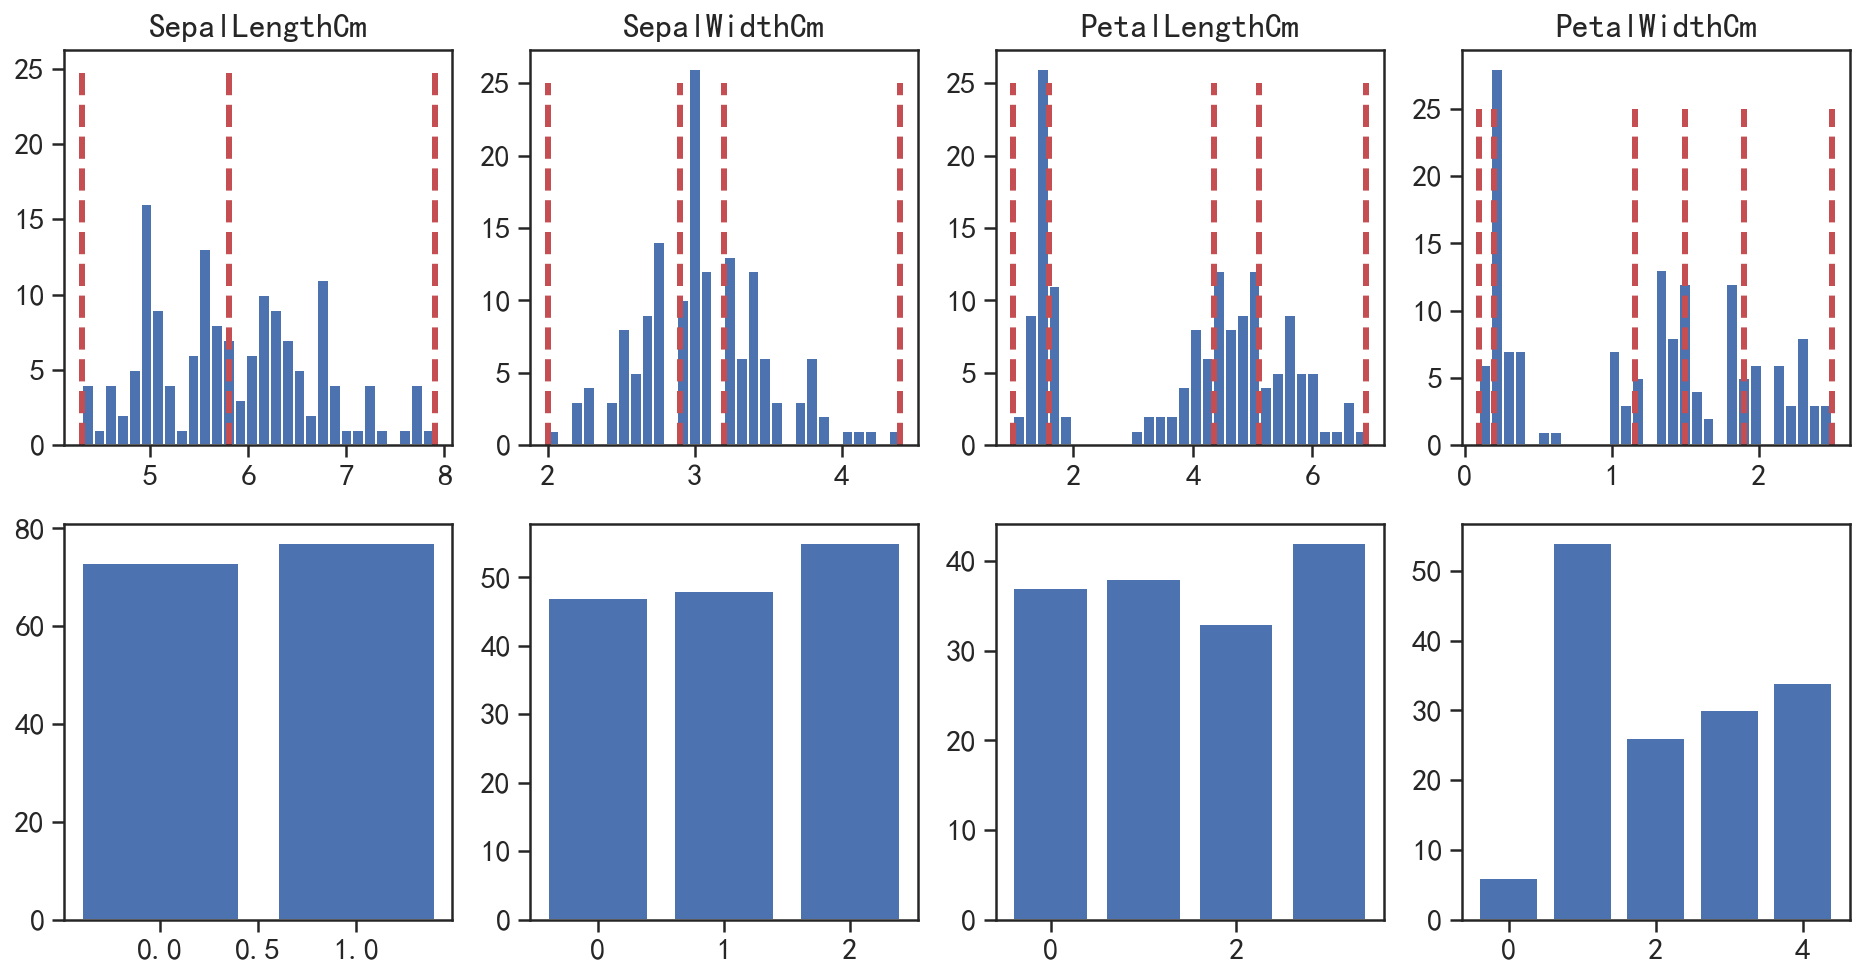

In [19]:
## 连续变量分箱，使用鸢尾花数据展示
X = Iris.iloc[:,1:5].values
n_bin = [2,3,4,5]
Kbins  = preprocessing.KBinsDiscretizer(n_bins=n_bin,    #每个变量分别分为2,3,4,5份 
                                        encode="ordinal",#分箱后的特征编码为整数
                                        strategy = "quantile") ## 利用分位数的分箱策略
X_Kbins = Kbins.fit_transform(X)
## 获取划分区间时的临界线
X_Kbins_edges = Kbins.bin_edges_

## 对分箱前后的数据进行可视化
plt.figure(figsize=(16,8))
## 可视化分箱前的特征
for ii in range(4):
    plt.subplot(2,4,ii+1)
    plt.hist(Iris.iloc[:,ii+1],bins = 30)
    plt.title(Iris.columns[ii+1])
    ## 可视化划分箱的临界线
    edges = X_Kbins_edges[ii]
    for edge in edges:
        plt.vlines(edge,0,25,colors="r",linewidth= 3,
                   linestyle='dashed')
## 可视化分箱后的特征
for ii,binsii in enumerate(n_bin):
    plt.subplot(2,4,ii+5)
    ## 计算每个元素出现的次数
    barx, height = np.unique(X_Kbins[:,ii], return_counts=True)
    plt.bar(barx,height)
plt.show()

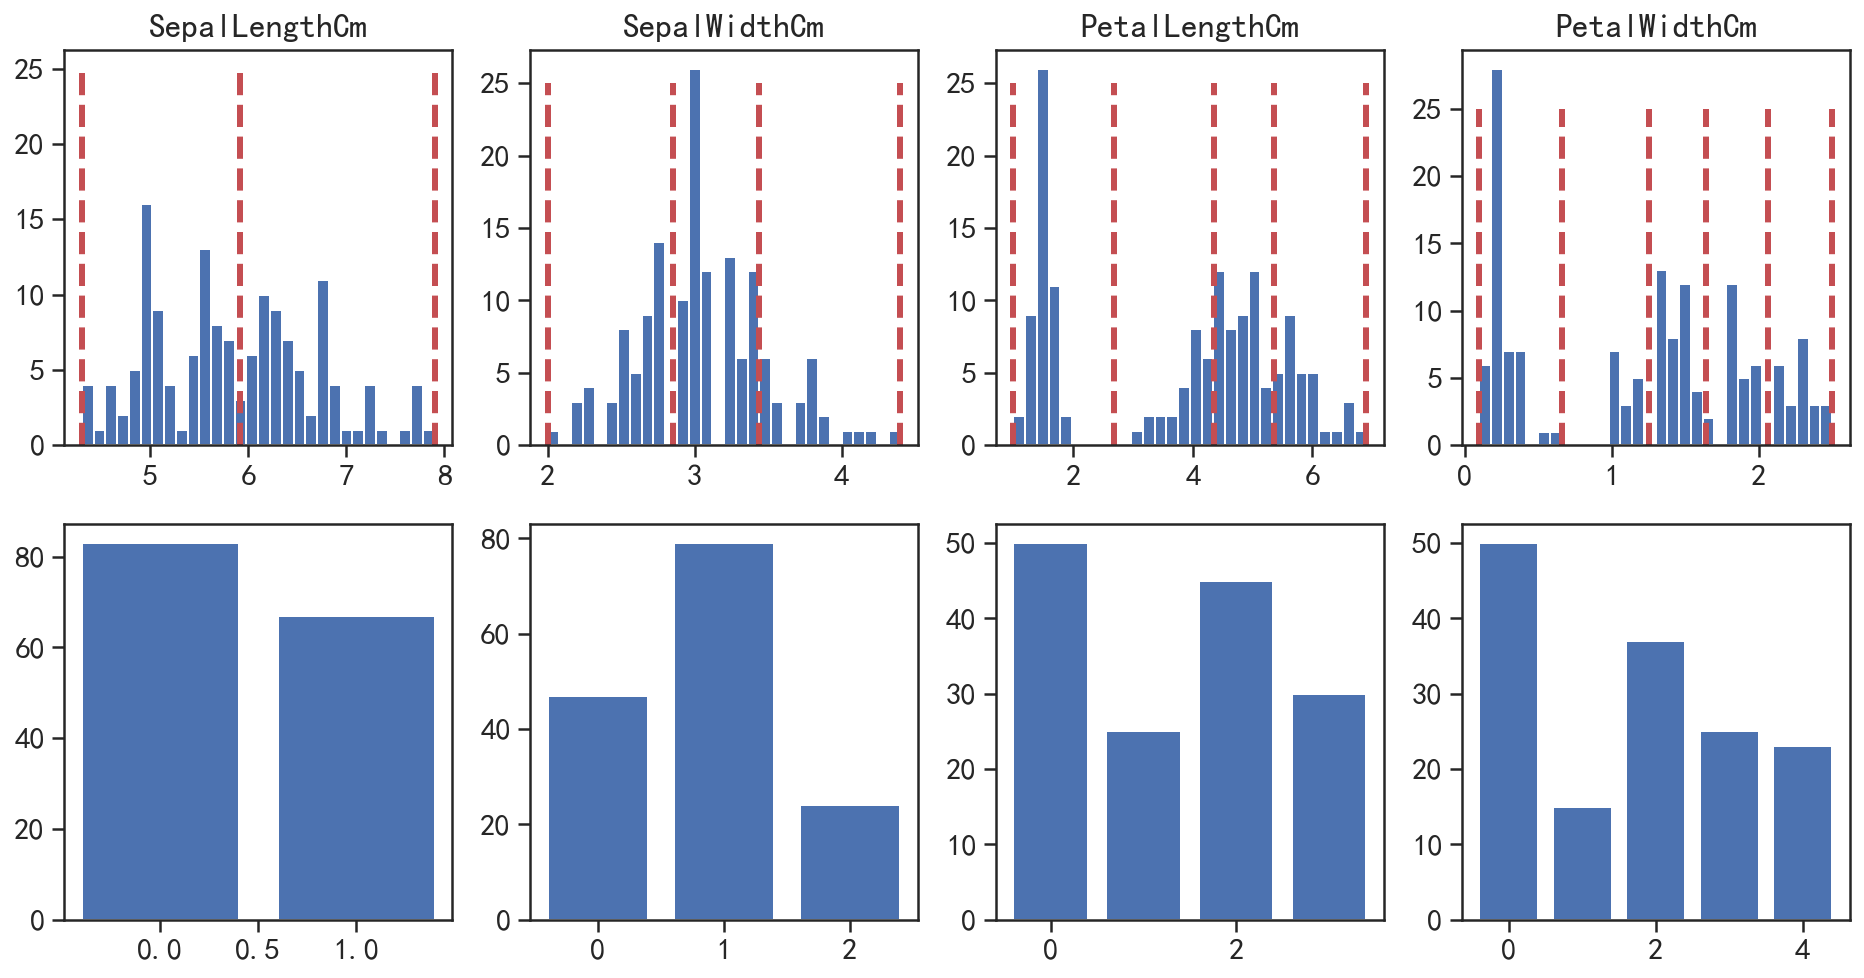

In [20]:
## 连续变量分箱，使用鸢尾花数据展示
X = Iris.iloc[:,1:5].values
n_bin = [2,3,4,5]
Kbins  = preprocessing.KBinsDiscretizer(n_bins=n_bin,    #每个变量分别分为2,3,4,5份 
                                        encode="ordinal",#分箱后的特征编码为整数
                                        strategy = "kmeans")##每个变量执行k均值聚类过程的分箱策略
X_Kbins = Kbins.fit_transform(X)
## 获取划分区间时的临界线
X_Kbins_edges = Kbins.bin_edges_

## 对分箱前后的数据进行可视化
plt.figure(figsize=(16,8))
## 可视化分箱前的特征
for ii in range(4):
    plt.subplot(2,4,ii+1)
    plt.hist(Iris.iloc[:,ii+1],bins = 30)
    plt.title(Iris.columns[ii+1])
    ## 可视化划分箱的临界线
    edges = X_Kbins_edges[ii]
    for edge in edges:
        plt.vlines(edge,0,25,colors="r",linewidth= 3,
                   linestyle='dashed')
## 可视化分箱后的特征
for ii,binsii in enumerate(n_bin):
    plt.subplot(2,4,ii+5)
    ## 计算每个元素出现的次数
    barx, height = np.unique(X_Kbins[:,ii], return_counts=True)
    plt.bar(barx,height)
plt.show()
        

#### 文本数据的特征构建

In [21]:
## 读取一个文本文件
textdf = pd.read_table("data/chap3/文本数据.txt",header=0)
print(textdf)

                                                text
0                                 I come from China.
1                                 My maijor is math.
2                       Life is short, I use Python.
3                  Python is a programming language.
4               Python, R and Matlab, I love Python.
5  My maijor is computer. He maijor is computer t...
6                        I come from Shanghai China.
7                   Life is short and happy in time.


In [22]:
## 将所有的大写字母转化为小写
textdf["text"] = textdf.text.apply(lambda x: x.lower())
## 剔除多余的空格和标点符号
textdf["text"] = textdf.text.apply(lambda x: re.sub('[^\w\s]','',x))
print(textdf)

                                                text
0                                  i come from china
1                                  my maijor is math
2                         life is short i use python
3                   python is a programming language
4                  python r and matlab i love python
5  my maijor is computer he maijor is computer te...
6                         i come from shanghai china
7                    life is short and happy in time


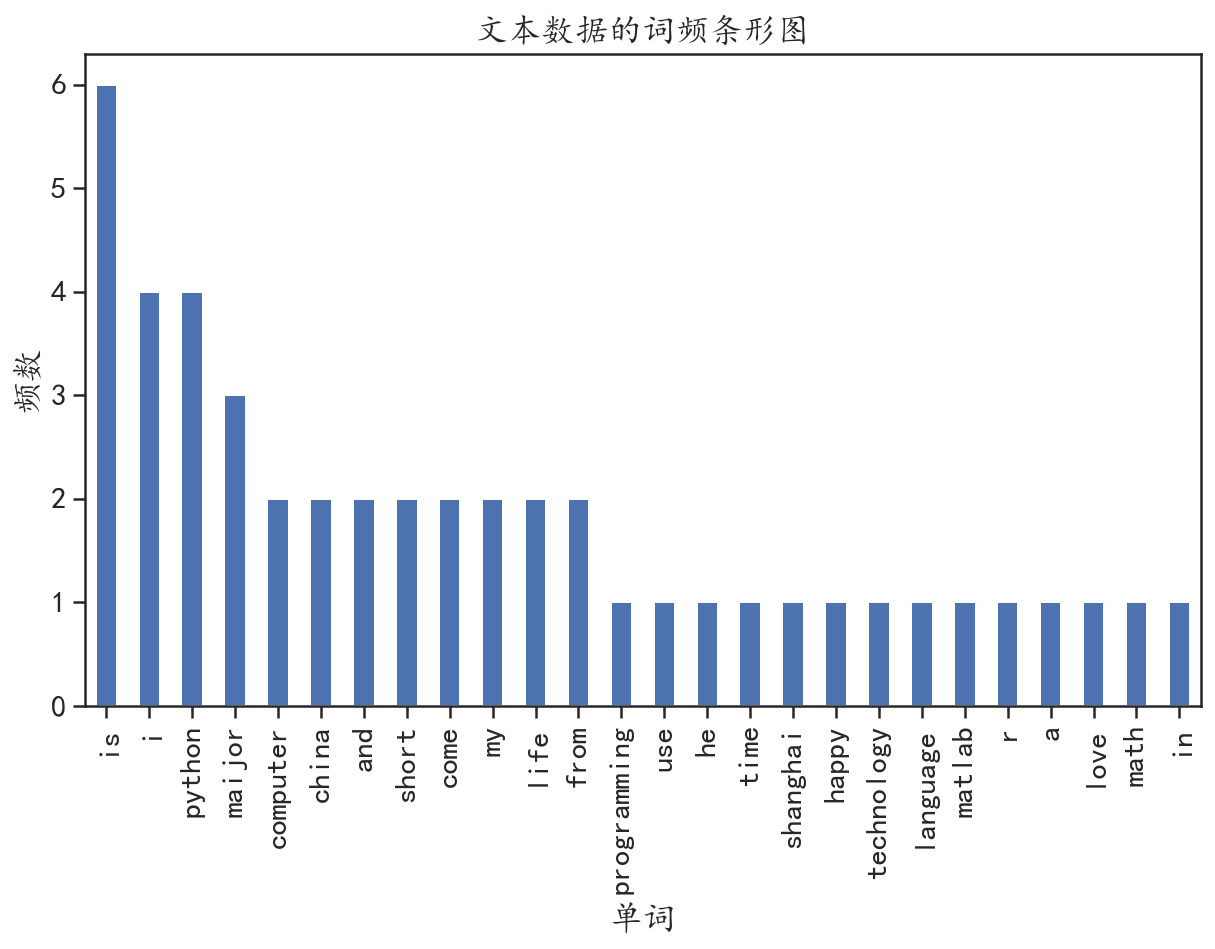

In [23]:
## 统计词频
text = " ".join(textdf.text) # 拼接字符串
text = text.split(" ")       # 分割字符串
## 计算每个词出现的次数
textfre = pd.Series(text).value_counts()
## 使用条形图可视化词频
textfre.plot(kind = "bar",figsize = (10,6),rot = 90)
plt.ylabel("频数")
plt.xlabel("单词")
plt.title("文本数据的词频条形图")
plt.show()

In [24]:
## 词袋模型（BoW）
## 是用于文本表示的最简单的方法， BoW把文本转换为文档中单词出现次数的矩阵，
## 该模型只关注文档中是否出现给定的单词和单词出现频率，而舍弃文本的结构、单词出现的顺序和位置
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer(stop_words = "english")  # 处理时会去除停用词
cv_matrix = cv.fit_transform(textdf.text)
## 为了便于分析，将得到的结果处理为数据表
cv_matrixdf = pd.DataFrame(data = cv_matrix.toarray(),
                           columns = cv.get_feature_names())
print(cv_matrixdf)

   china  come  computer  happy  language  life  love  maijor  math  matlab  \
0      1     1         0      0         0     0     0       0     0       0   
1      0     0         0      0         0     0     0       1     1       0   
2      0     0         0      0         0     1     0       0     0       0   
3      0     0         0      0         1     0     0       0     0       0   
4      0     0         0      0         0     0     1       0     0       1   
5      0     0         2      0         0     0     0       2     0       0   
6      1     1         0      0         0     0     0       0     0       0   
7      0     0         0      1         0     1     0       0     0       0   

   programming  python  shanghai  short  technology  time  use  
0            0       0         0      0           0     0    0  
1            0       0         0      0           0     0    0  
2            0       1         0      1           0     0    1  
3            1       1      

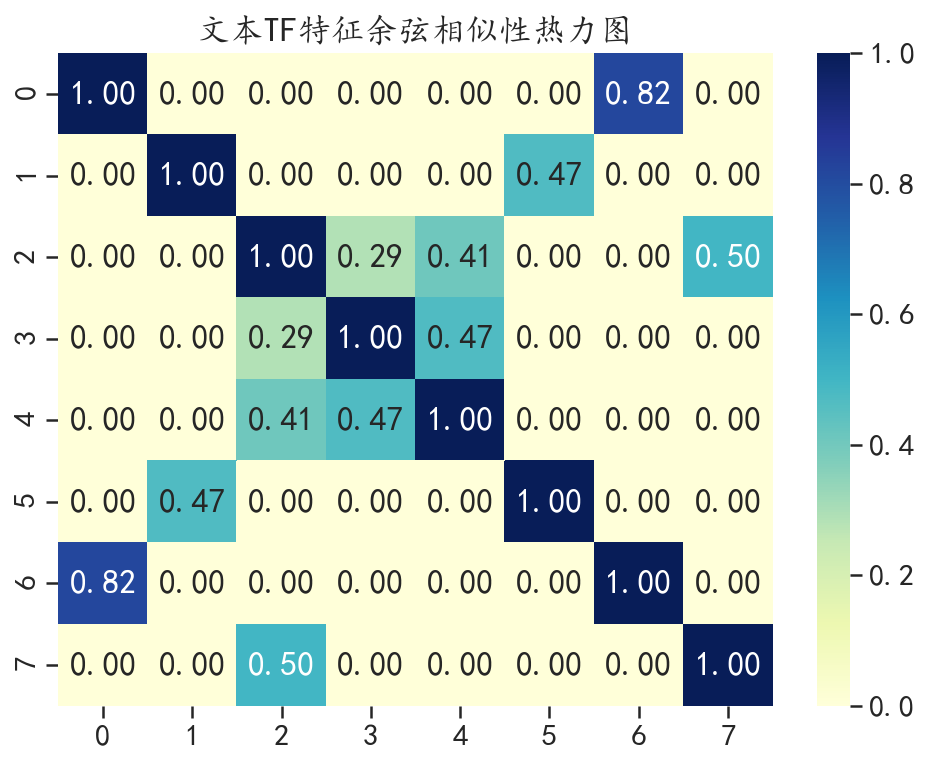

In [25]:
## 通过余弦相似性计算文本之间的相关系数
from sklearn.metrics.pairwise import cosine_similarity
textcosin = cosine_similarity(cv_matrixdf)
## 使用热力图可视化相关性
plt.figure(figsize=(8,6))
ax = sns.heatmap(textcosin,fmt=".2f",annot=True,cmap="YlGnBu")
plt.title("文本TF特征余弦相似性热力图")
plt.show()

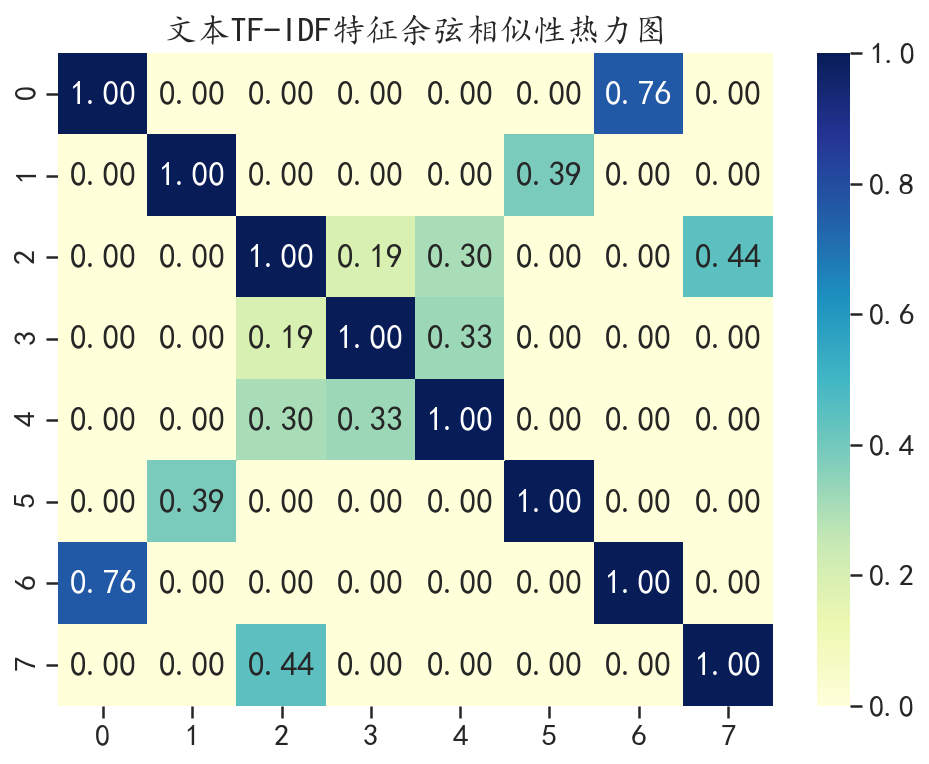

In [26]:
## 获取文本的tf-idf特征
TFIDF = TfidfVectorizer(stop_words = "english")
TFIDF_mat = TFIDF.fit_transform(textdf.text).toarray()
## 计算余弦相似性并可视化
textcosin = cosine_similarity(TFIDF_mat)
## 使用热力图可视化相关性
plt.figure(figsize=(8,6))
ax = sns.heatmap(textcosin,fmt=".2f",annot=True,cmap="YlGnBu")
plt.title("文本TF-IDF特征余弦相似性热力图")
plt.show()

### 3.3 特征选择

In [27]:
from sklearn.feature_selection import VarianceThreshold,f_classif

In [28]:
## 导入取酒的多分类数据集，用于演示
from sklearn.datasets import load_wine
wine_x,wine_y = load_wine(return_X_y=True)
print(wine_x.shape)
print(np.unique(wine_y,return_counts = True))

(178, 13)
(array([0, 1, 2]), array([59, 71, 48]))


In [29]:
np.min(wine_x,axis = 0)

array([1.103e+01, 7.400e-01, 1.360e+00, 1.060e+01, 7.000e+01, 9.800e-01,
       3.400e-01, 1.300e-01, 4.100e-01, 1.280e+00, 4.800e-01, 1.270e+00,
       2.780e+02])

#### 基于统计方法选择

In [30]:
## 删除低方差的特征
from sklearn.feature_selection import VarianceThreshold
VTH = VarianceThreshold(threshold = 0.5)
VTH_wine_x = VTH.fit_transform(wine_x)
print(VTH_wine_x.shape)

## 可见只保留了8个方差大于0.5的特征

(178, 8)


In [31]:
## 保留的变量
VTH.variances_ > 0.5

array([ True,  True, False,  True,  True, False,  True, False, False,
        True, False,  True,  True])

In [32]:
## 选择K个最高得分的变量，分类可使用chi2, f_classif,mutual_info_classif等
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
## 通过方差分析的F值选择K个变量
KbestF = SelectKBest(f_classif, k=5)
KbestF_wine_x = KbestF.fit_transform(wine_x,wine_y)
print(KbestF_wine_x.shape)

(178, 5)


In [33]:
## 通过卡方值值选择K个变量
KbestChi2 = SelectKBest(chi2, k=5)
KbestChi2_wine_x = KbestF.fit_transform(wine_x,wine_y)
print(KbestChi2_wine_x.shape)

(178, 5)


In [34]:
## 通过互信息选择K个变量
KbestMI = SelectKBest(mutual_info_classif, k=5)
KbestMI_wine_x = KbestMI.fit_transform(wine_x,wine_y)
print(KbestMI_wine_x.shape)

## 针对回归问题的K个最高得分的选择，可以使用f_regression，mutual_info_regression等统计量

(178, 5)


#### 基于递归消除特征法

In [35]:
## 递归消除特征法
## 使用一个基模型来进行多轮训练，每轮训练后，消除若干权值系数的特征，再基于新的特征集进行下一轮训练。
## 它使用模型精度来识别哪些属性（和属性组合）对预测目标属性的贡献最大
from sklearn.feature_selection import RFE,RFECV
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=0) #设置基模型为随机森林
rfe = RFE(estimator = model,n_features_to_select = 9) #选择9个最佳特征变量
rfe_wine_x = rfe.fit_transform(wine_x, wine_y) #进行RFE递归
print("特征是否被选中:\n",rfe.support_)  
print("获取的数据特征尺寸:",rfe_wine_x.shape)

## True表示对应的特征被选中

特征是否被选中:
 [ True False False  True  True  True  True False False  True  True  True
  True]
获取的数据特征尺寸: (178, 9)


In [36]:
#设置基模型为随机森林
model = RandomForestClassifier(random_state=0) 
# 借助5折交叉验证最少选择5个最佳特征变量
rfecv = RFECV(estimator = model,min_features_to_select = 5, cv = 5) 
rfecv_wine_x = rfecv.fit_transform(wine_x, wine_y) #进行RFE递归
print("特征是否被选中:\n",rfecv.support_)  
print("获取的数据特征尺寸:",rfecv_wine_x.shape)

## True表示对应的特征被选中,可以发现选择了12个特征，只剔除了一个特征

特征是否被选中:
 [ True  True False  True  True  True  True  True  True  True  True  True
  True]
获取的数据特征尺寸: (178, 12)


#### 基于机器学习的方法

In [37]:
## 根据特征的重要性权重选择特征
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

## 利用随机森林模型进行特征的选择
rfc = RandomForestClassifier(n_estimators=100,random_state=0)
rfc = rfc.fit(wine_x,wine_y) # 使用模型拟合数据
## 定义从模型中进行特征选择的选择器
sfm = SelectFromModel(estimator=rfc, ## 进行特征选择的模型
                      prefit = True, ## 对模型进行预训练
                      max_features = 10,##选择的最大特征数量
                     )
## 将模型选择器作用于数据特征
sfm_wine_x = sfm.transform(wine_x)
print(sfm_wine_x.shape)

## 可见针对数据的分类问题选择出6个重要的数据特征

(178, 6)


In [38]:
## 在特征的选择时还可以利用L1范数进行选择
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import LinearSVC

## 在构建支持向量机分类时使用L1范数约束
svc = LinearSVC(penalty="l1",dual=False,C = 0.05)
svc = svc.fit(wine_x,wine_y)
## 定义从模型中进行特征选择的选择器
sfm = SelectFromModel(estimator=svc, ## 进行特征选择的模型
                      prefit = True, ## 对模型进行预训练
                      max_features = 10,##选择的最大特征数量
                     )
## 将模型选择器作用于数据特征
sfm_wine_x = sfm.transform(wine_x)
print(sfm_wine_x.shape)

## 可见针对数据的分类问题选择出8个重要的数据特征

(178, 8)


### 3.4 特征提取和降维

In [39]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import Isomap, MDS, TSNE
from sklearn.preprocessing import StandardScaler
## 对酒的特征数据进行标准化
wine_x,wine_y = load_wine(return_X_y=True)
wine_x = StandardScaler().fit_transform(wine_x)

#### 主成分分析

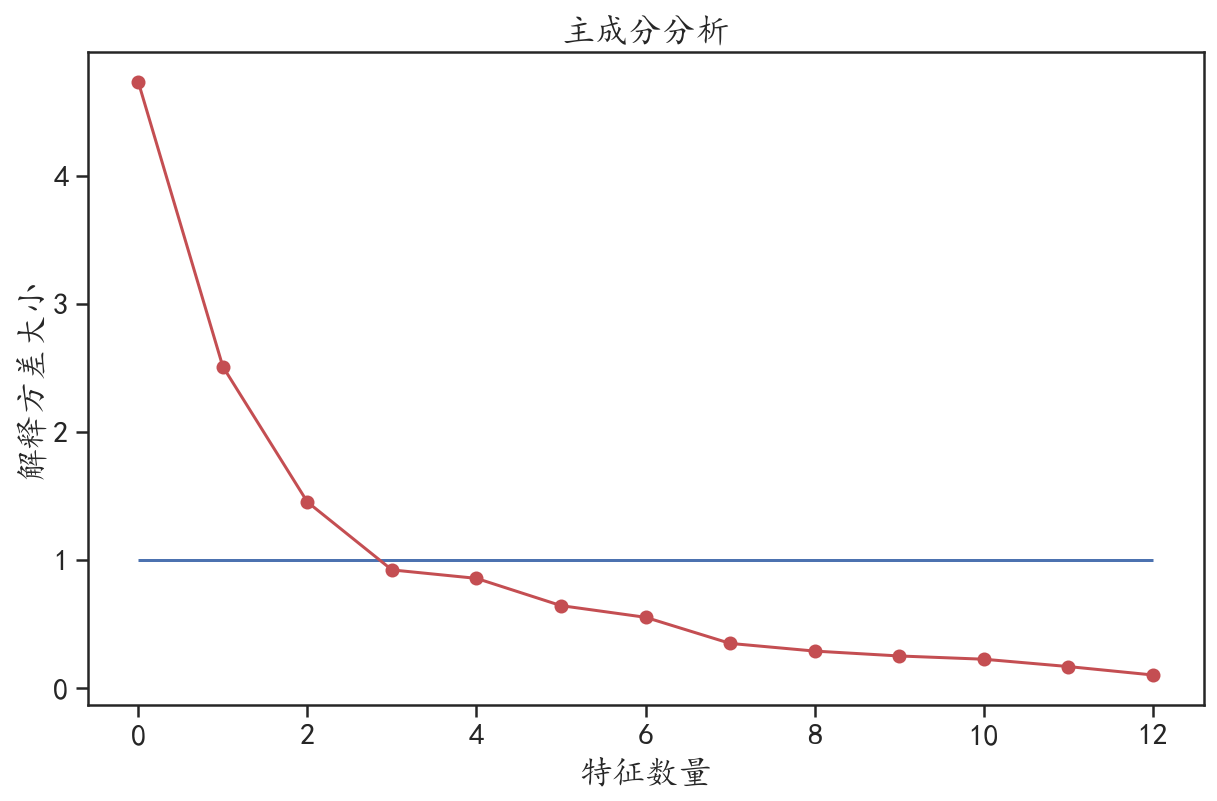

In [40]:
## 使用主成分分析对酒数据集进行降维
pca = PCA(n_components = 13,random_state = 123)
pca.fit(wine_x)
## 可视化主成分分析的解释方差得分
exvar = pca.explained_variance_
plt.figure(figsize=(10,6))
plt.plot(exvar,"r-o")
plt.hlines(y = 1, xmin = 0, xmax = 12)
plt.xlabel("特征数量")
plt.ylabel("解释方差大小")
plt.title("主成分分析")
plt.show()

(178, 3)


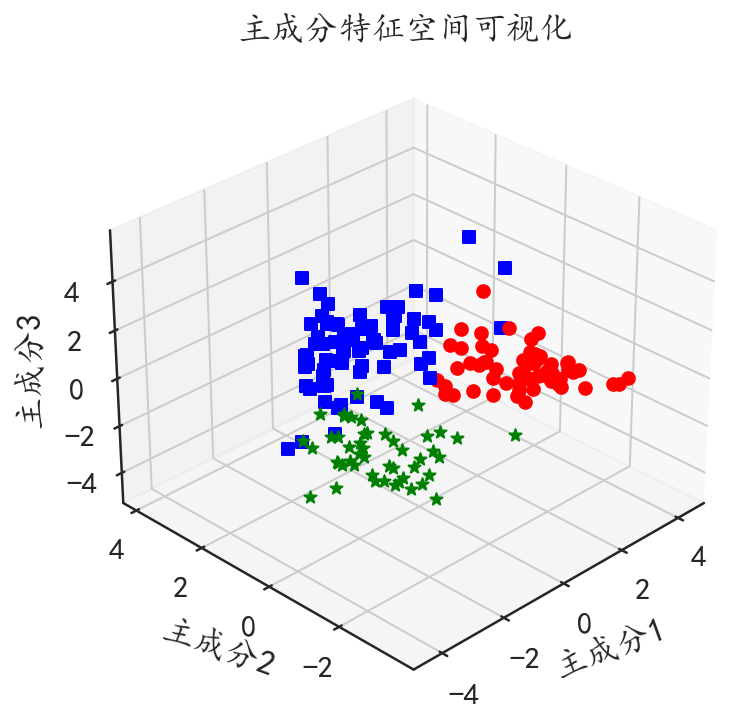

In [55]:
## 可以发现使用数据的前3个主成分较合适
pca_wine_x = pca.transform(wine_x)[:,0:3]
print(pca_wine_x.shape)
## 在3D空间中可视化主成分分析后的数据空间分布
colors = ["red","blue","green"]
shapes = ["o","s","*"]
fig = plt.figure(figsize=(10,6))
## 将坐标系设置为3D
ax1 = fig.add_subplot(111, projection="3d")
for ii,y in enumerate(wine_y):
    ax1.scatter(pca_wine_x[ii,0],pca_wine_x[ii,1],pca_wine_x[ii,2],
                s = 40,c = colors[y],marker = shapes[y])
ax1.set_xlabel("主成分1",rotation=20)
ax1.set_ylabel("主成分2",rotation=-20)
ax1.set_zlabel("主成分3",rotation=90)
ax1.azim = 225
ax1.set_title("主成分特征空间可视化")
plt.show()

#### 核主成分分析

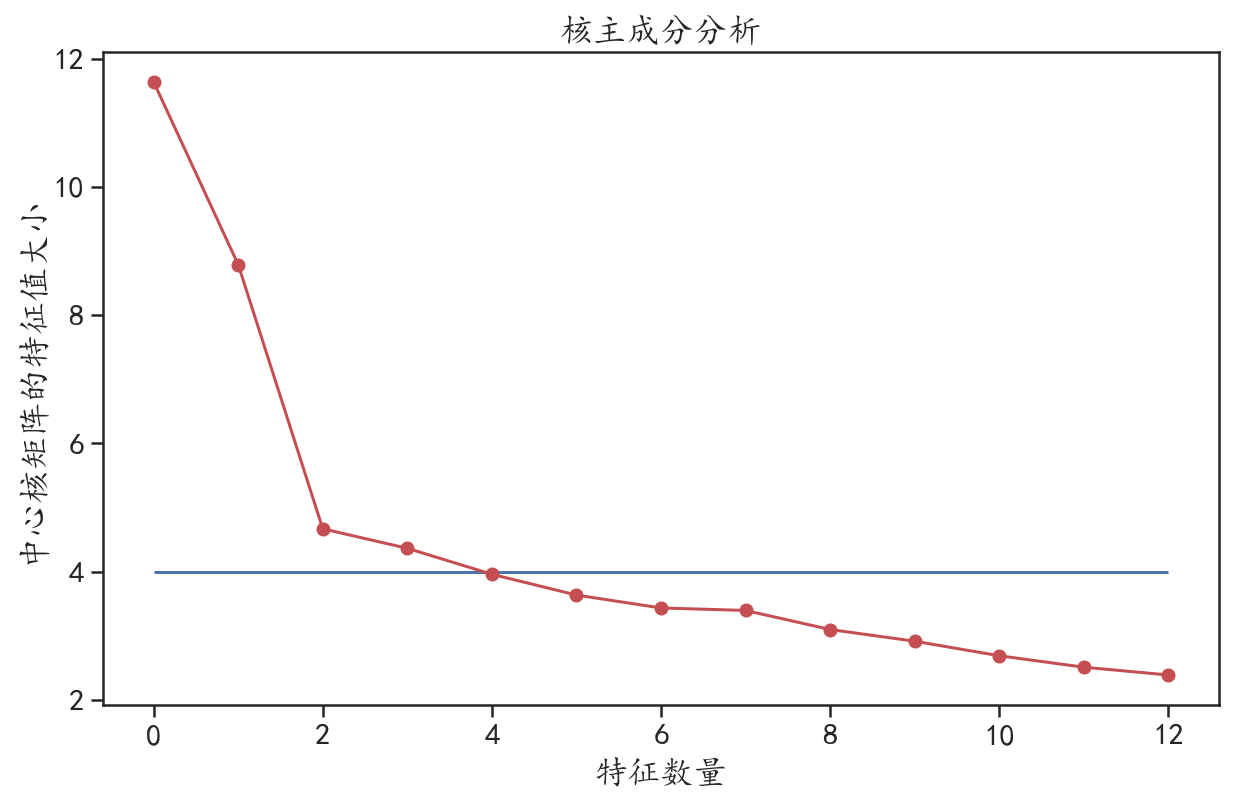

In [42]:
## 使用核主成分分析获取数据的主成分
kpca = KernelPCA(n_components = 13,kernel = "rbf", ## 核函数为rbf核
                 gamma = 0.2,random_state = 123)
kpca.fit(wine_x)
## 可视化核主成分分析的中心矩阵特征值
lambdas = kpca.lambdas_
plt.figure(figsize=(10,6))
plt.plot(lambdas,"r-o")
plt.hlines(y = 4, xmin = 0, xmax = 12)
plt.xlabel("特征数量")
plt.ylabel("中心核矩阵的特征值大小")
plt.title("核主成分分析")
plt.show()

## 可以发现使用数据的前3个核主成分较合适

(178, 3)


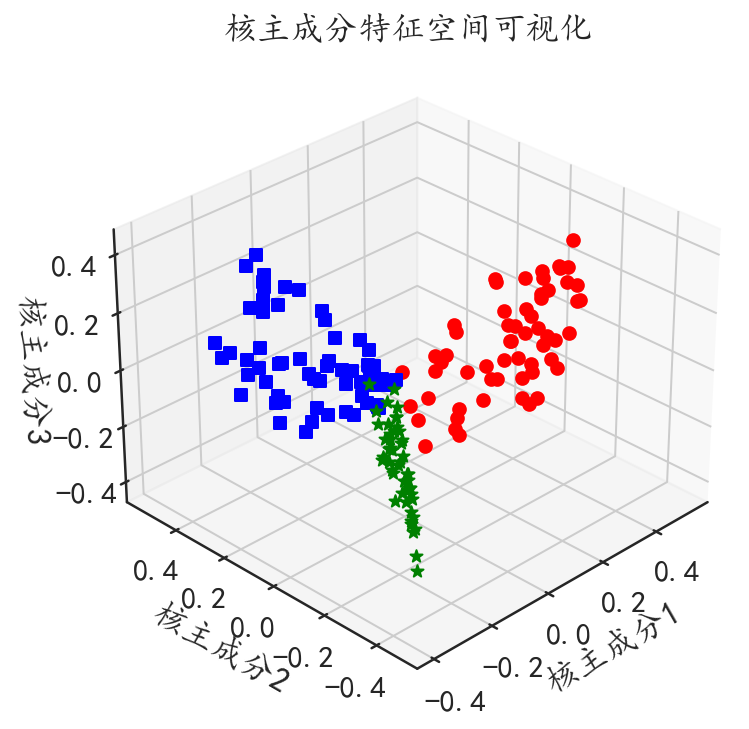

In [43]:
## 获取前3个核主成分
kpca_wine_x = kpca.transform(wine_x)[:,0:3]
print(kpca_wine_x.shape)
## 在3D空间中可视化主成分分析后的数据空间分布
colors = ["red","blue","green"]
shapes = ["o","s","*"]
fig = plt.figure(figsize=(10,6))
## 将坐标系设置为3D
ax1 = fig.add_subplot(111, projection="3d")
for ii,y in enumerate(wine_y):
    ax1.scatter(kpca_wine_x[ii,0],kpca_wine_x[ii,1],kpca_wine_x[ii,2],
                s = 40,c = colors[y],marker = shapes[y])
ax1.set_xlabel("核主成分1",rotation=20)
ax1.set_ylabel("核主成分2",rotation=-20)
ax1.set_zlabel("核主成分3",rotation=90)
ax1.azim = 225
ax1.set_title("核主成分特征空间可视化")
plt.show()

#### 流形学习

(178, 3)


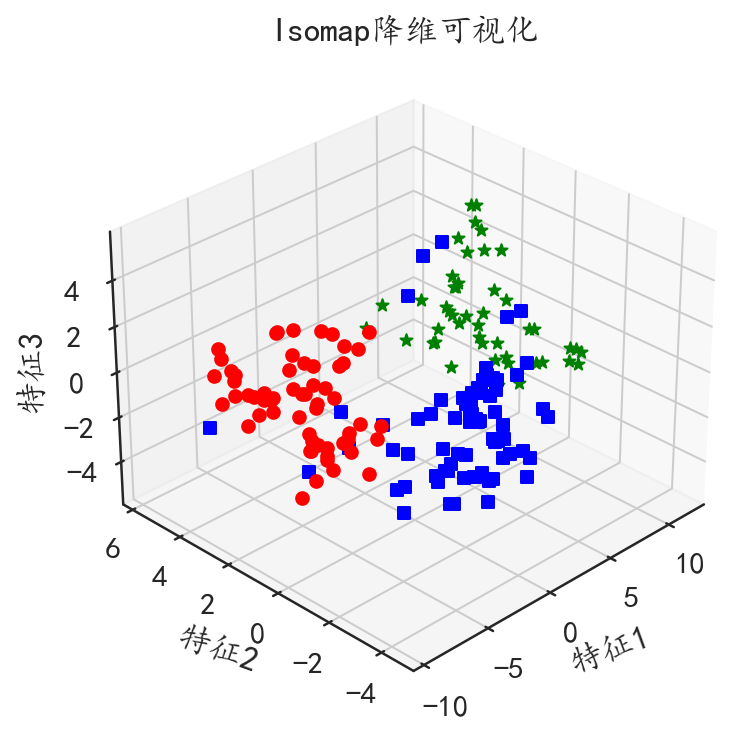

In [44]:
## 流行学习进行数据的非线性降维
isomap = Isomap(n_neighbors = 7,## 每个点考虑的近邻数量
                n_components = 3) ## 降维到3维空间中


## 获取降维后的数据
isomap_wine_x = isomap.fit_transform(wine_x)
print(isomap_wine_x.shape)
## 在3D空间中可视化流行降维后的数据空间分布
colors = ["red","blue","green"]
shapes = ["o","s","*"]
fig = plt.figure(figsize=(10,6))
## 将坐标系设置为3D
ax1 = fig.add_subplot(111, projection="3d")
for ii,y in enumerate(wine_y):
    ax1.scatter(isomap_wine_x[ii,0],isomap_wine_x[ii,1],isomap_wine_x[ii,2],
                s = 40,c = colors[y],marker = shapes[y])
ax1.set_xlabel("特征1",rotation=20)
ax1.set_ylabel("特征2",rotation=-20)
ax1.set_zlabel("特征3",rotation=90)
ax1.azim = 225
ax1.set_title("Isomap降维可视化")
plt.show()


#### TSNE

(178, 3)


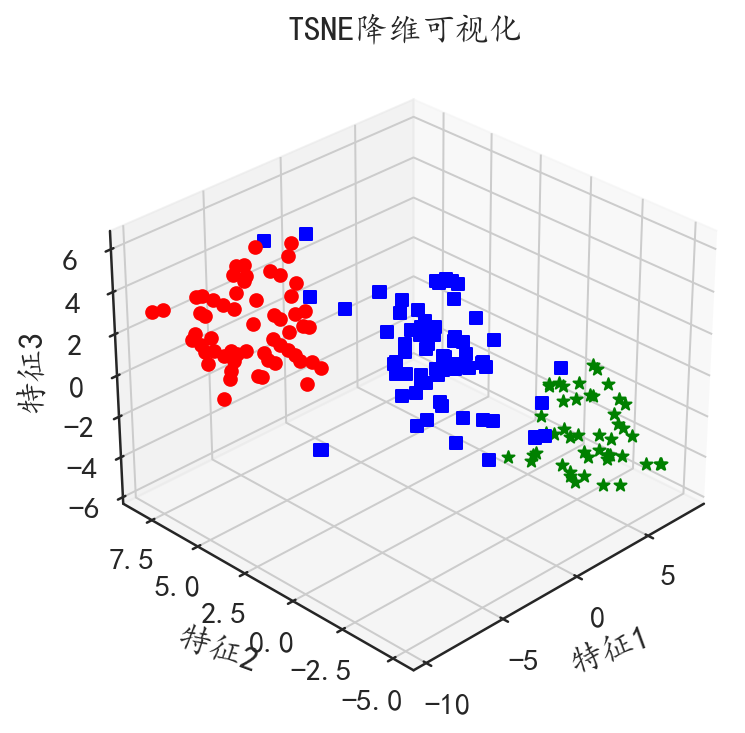

In [45]:
## TSNE进行数据的降维,降维到3维空间中
tsne = TSNE(n_components = 3,perplexity =25,
            early_exaggeration =3,random_state=123) 


## 获取降维后的数据
tsne_wine_x = tsne.fit_transform(wine_x)
print(tsne_wine_x.shape)
## 在3D空间中可视化流行降维后的数据空间分布
colors = ["red","blue","green"]
shapes = ["o","s","*"]
fig = plt.figure(figsize=(10,6))
## 将坐标系设置为3D
ax1 = fig.add_subplot(111, projection="3d")
for ii,y in enumerate(wine_y):
    ax1.scatter(tsne_wine_x[ii,0],tsne_wine_x[ii,1],tsne_wine_x[ii,2],
                s = 40,c = colors[y],marker = shapes[y])
ax1.set_xlabel("特征1",rotation=20)
ax1.set_ylabel("特征2",rotation=-20)
ax1.set_zlabel("特征3",rotation=90)
ax1.azim = 225
ax1.set_title("TSNE降维可视化")
plt.show()

#### 多维尺度变换

(178, 3)


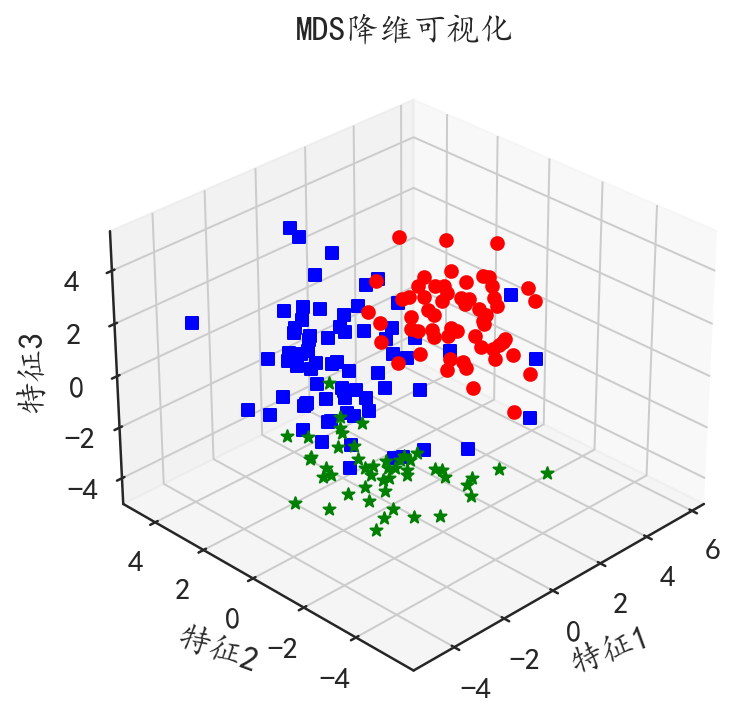

In [46]:
## MDS进行数据的降维,降维到3维空间中
mds = MDS(n_components = 3,dissimilarity = "euclidean",random_state=123) 
## 获取降维后的数据
mds_wine_x = mds.fit_transform(wine_x)
print(mds_wine_x.shape)
## 在3D空间中可视化流行降维后的数据空间分布
colors = ["red","blue","green"]
shapes = ["o","s","*"]
fig = plt.figure(figsize=(10,6))
## 将坐标系设置为3D
ax1 = fig.add_subplot(111, projection="3d")
for ii,y in enumerate(wine_y):
    ax1.scatter(mds_wine_x[ii,0],mds_wine_x[ii,1],mds_wine_x[ii,2],
                s = 40,c = colors[y],marker = shapes[y])
ax1.set_xlabel("特征1",rotation=20)
ax1.set_ylabel("特征2",rotation=-20)
ax1.set_zlabel("特征3",rotation=90)
ax1.azim = 225
ax1.set_title("MDS降维可视化")
plt.show()

### 3.5 数据平衡方法

In [47]:
## 建议使用较高版本的scikit-learn，例如：pip install scikit-learn==0.23.1
from imblearn.datasets import make_imbalance          
from imblearn.over_sampling import KMeansSMOTE,SMOTE,SVMSMOTE
from imblearn.under_sampling import AllKNN,CondensedNearestNeighbour,NearMiss
from imblearn.combine import SMOTEENN,SMOTETomek

## 将主成分分析提取的特征处理为类不平衡数据
im_x,im_y = make_imbalance(pca_wine_x,wine_y,
                           sampling_strategy={0: 30, 1: 70, 2: 20},
                           random_state=12)
print(np.unique(im_y,return_counts = True))

(array([0, 1, 2]), array([30, 70, 20]))


#### 基于过采样方法

In [48]:
## 使用过采样算法KMeansSMOTE进行数据平衡
kmeans = KMeansSMOTE(random_state=123, k_neighbors=3)
kmeans_x, kmeans_y = kmeans.fit_resample(im_x,im_y)
print("KMeansSMOTE : ",np.unique(kmeans_y,return_counts = True))

## 使用过采样算法SMOTE进行数据平衡
smote = SMOTE(random_state=123, k_neighbors=3)
smote_x, smote_y = smote.fit_resample(im_x,im_y)
print("SMOTE : ",np.unique(smote_y,return_counts = True))

## 使用过采样算法SVMSMOTE进行数据平衡
svms = SVMSMOTE(random_state=123, k_neighbors=3)
svms_x, svms_y = svms.fit_resample(im_x,im_y)
print("SVMSMOTE : ",np.unique(svms_y,return_counts = True))

KMeansSMOTE :  (array([0, 1, 2]), array([71, 70, 70]))
SMOTE :  (array([0, 1, 2]), array([70, 70, 70]))
SVMSMOTE :  (array([0, 1, 2]), array([70, 70, 53]))


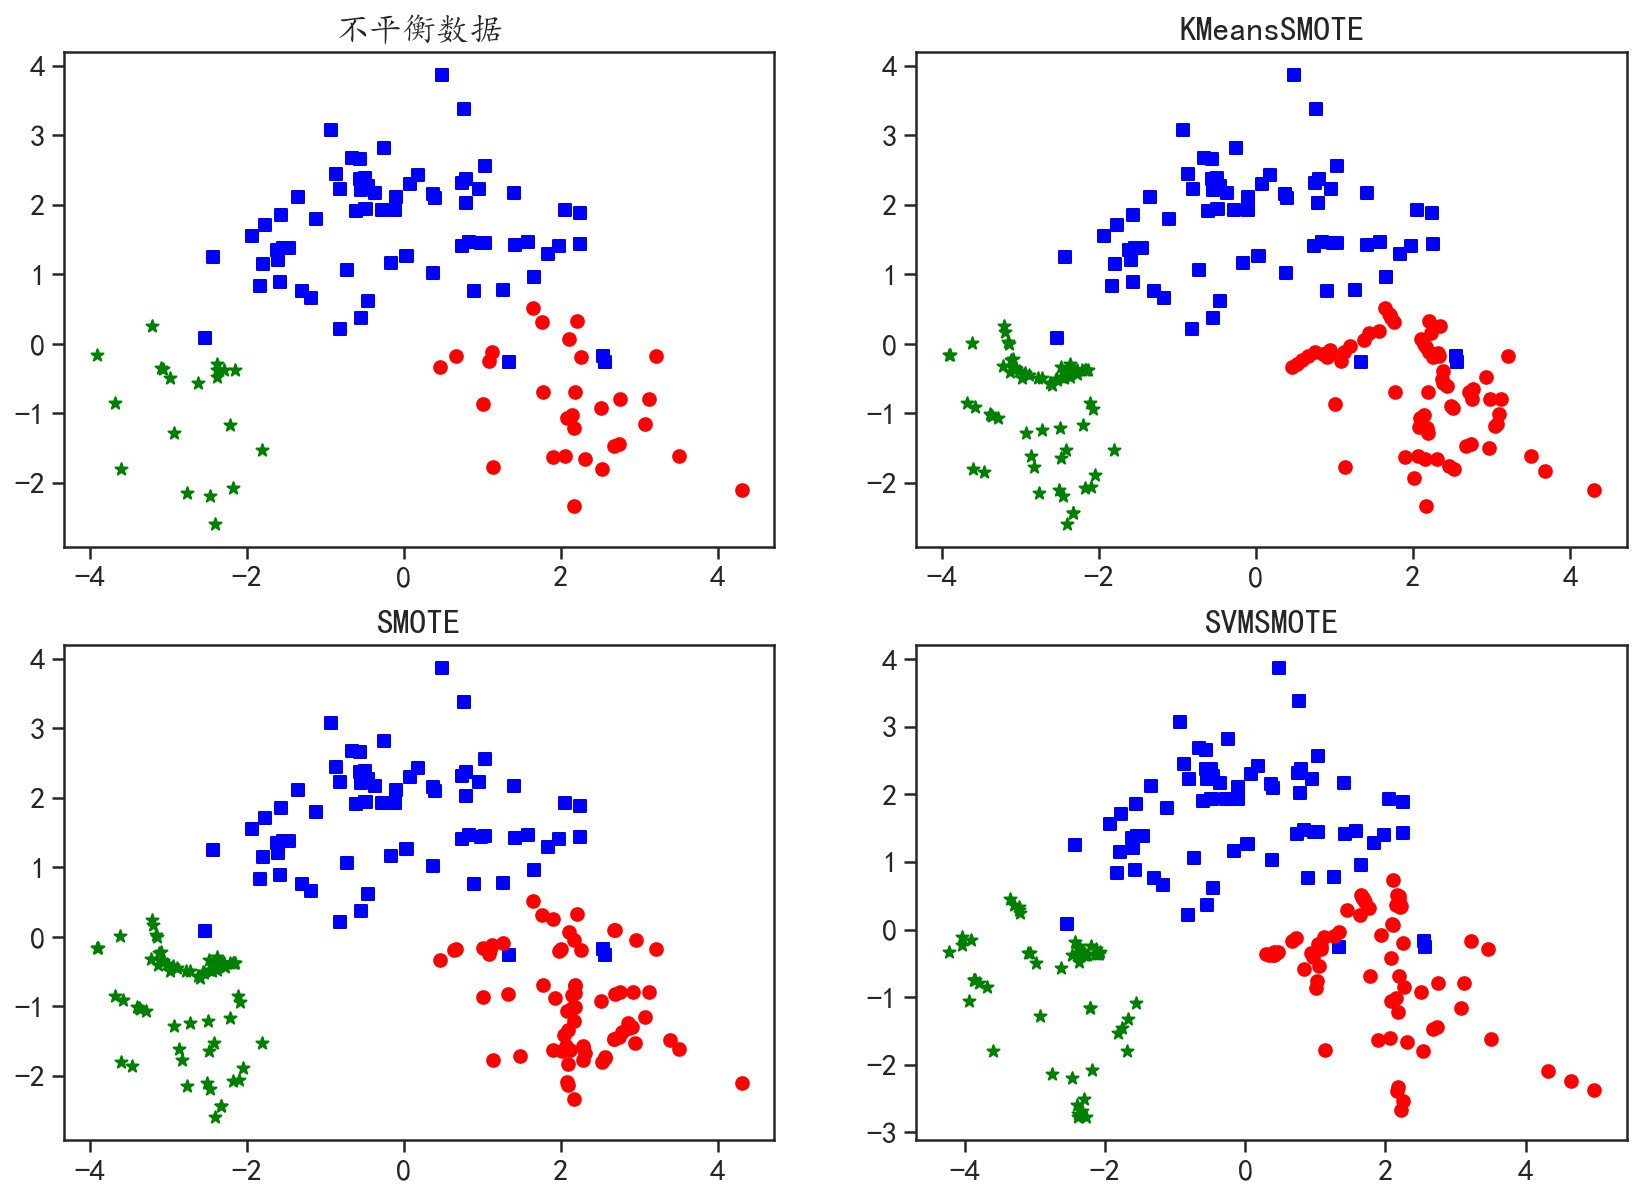

In [49]:
## 可视化不同算法下的数据可视化结果，使用二维散点图
colors = ["red","blue","green"]
shapes = ["o","s","*"]
fig = plt.figure(figsize=(14,10))
## 原始数据分布
plt.subplot(2,2,1)
for ii,y in enumerate(im_y):
    plt.scatter(im_x[ii,0],im_x[ii,1],s = 40,
                c = colors[y],marker = shapes[y])
    plt.title("不平衡数据")
## 过采样算法KMeansSMOTE
plt.subplot(2,2,2)
for ii,y in enumerate(kmeans_y):
    plt.scatter(kmeans_x[ii,0],kmeans_x[ii,1],s = 40,
                c = colors[y],marker = shapes[y])
    plt.title("KMeansSMOTE")
## 过采样算法SMOTE
plt.subplot(2,2,3)
for ii,y in enumerate(smote_y):
    plt.scatter(smote_x[ii,0],smote_x[ii,1],s = 40,
                c = colors[y],marker = shapes[y])
    plt.title("SMOTE")
## 过采样算法SVMSMOTE
plt.subplot(2,2,4)
for ii,y in enumerate(svms_y):
    plt.scatter(svms_x[ii,0],svms_x[ii,1],s = 40,
                c = colors[y],marker = shapes[y])
    plt.title("SVMSMOTE")
plt.show()

#### 基于欠采样方法

In [50]:
## 使用欠采样算法CondensedNearestNeighbour进行数据平衡
cnn = CondensedNearestNeighbour(random_state=123, n_neighbors=7,n_seeds_S = 20)
cnn_x, cnn_y = cnn.fit_resample(im_x,im_y)
print("CondensedNearestNeighbour : ",np.unique(cnn_y,return_counts = True))

## 使用欠采样算法AllKNN进行数据平衡
allknn = AllKNN(n_neighbors=10)
allknn_x, allknn_y = allknn.fit_resample(im_x,im_y)
print("AllKNN : ",np.unique(allknn_y,return_counts = True))

## 使用欠采样算法NearMiss进行数据平衡
nmiss = NearMiss(n_neighbors=3)
nmiss_x, nmiss_y = nmiss.fit_resample(im_x,im_y)
print("NearMiss : ",np.unique(nmiss_y,return_counts = True))

CondensedNearestNeighbour :  (array([0, 1, 2]), array([20, 23, 20]))
AllKNN :  (array([0, 1, 2]), array([21, 54, 20]))
NearMiss :  (array([0, 1, 2]), array([20, 20, 20]))


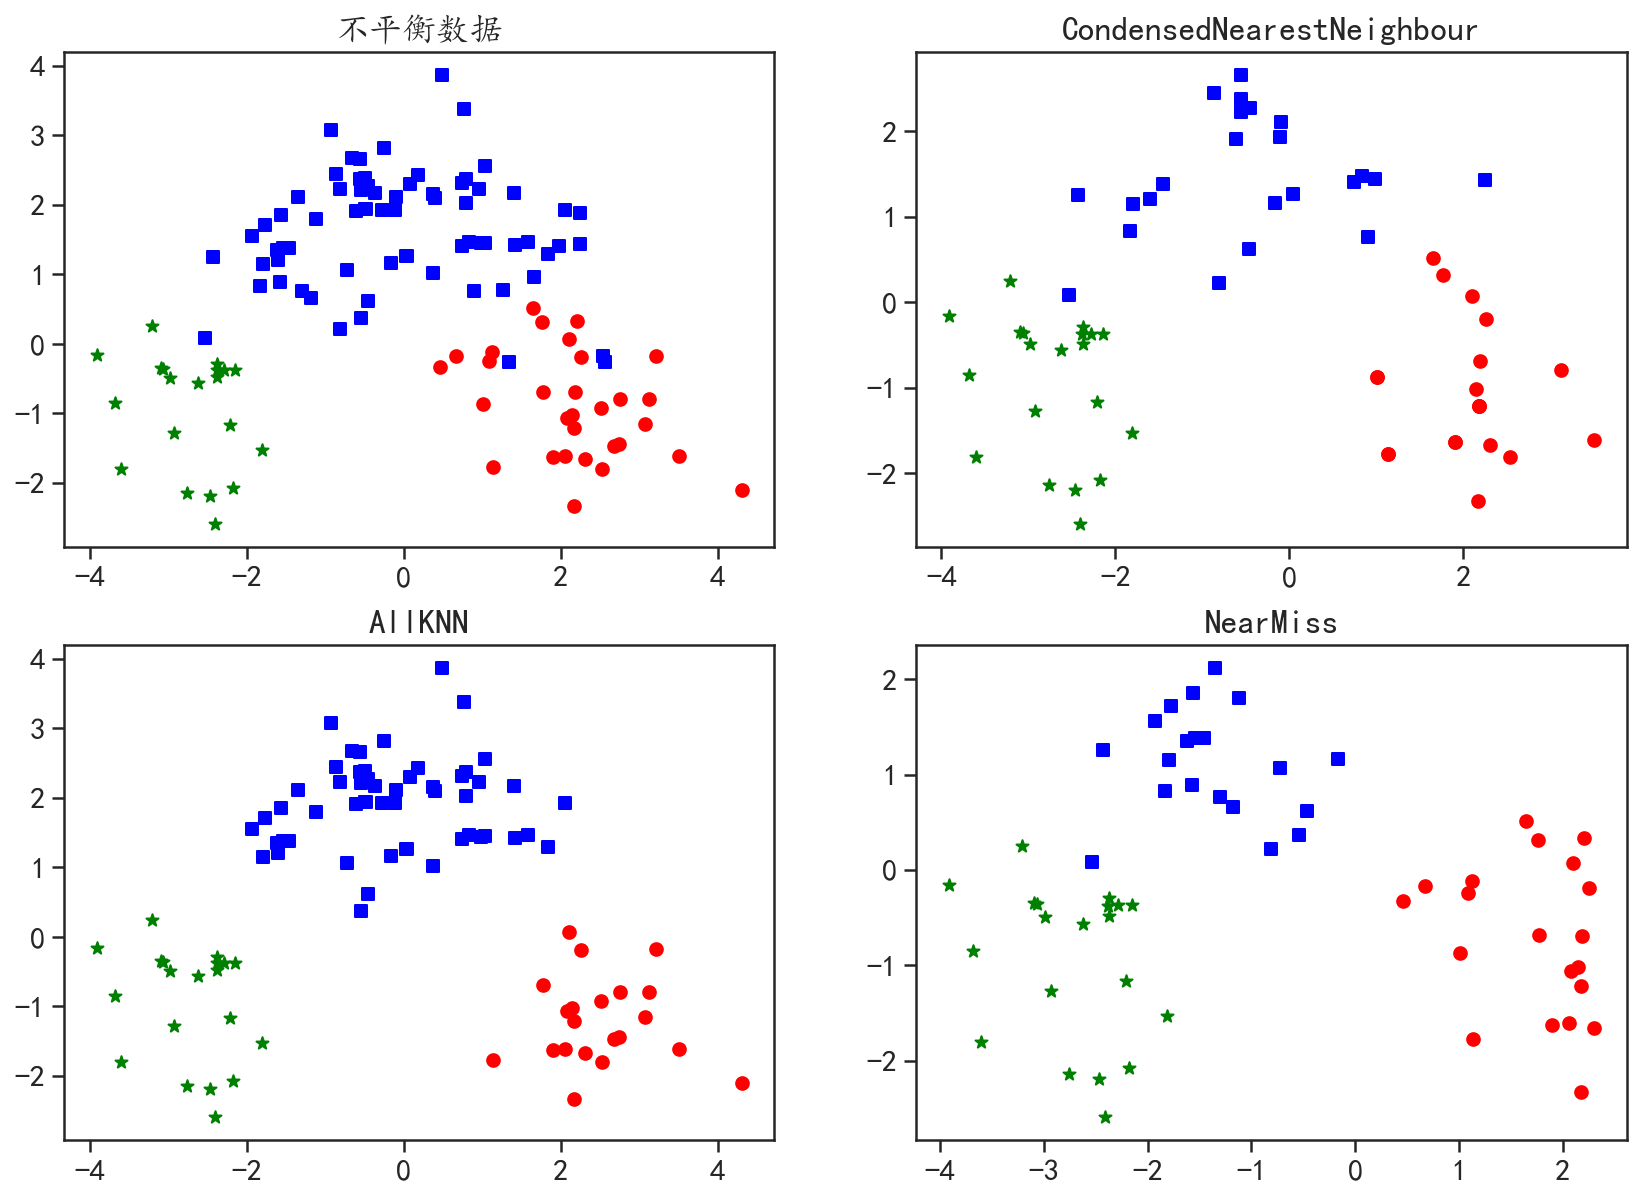

In [51]:
## 可视化不同算法下的数据可视化结果，使用二维散点图
colors = ["red","blue","green"]
shapes = ["o","s","*"]
fig = plt.figure(figsize=(14,10))
## 原始数据分布
plt.subplot(2,2,1)
for ii,y in enumerate(im_y):
    plt.scatter(im_x[ii,0],im_x[ii,1],s = 40,
                c = colors[y],marker = shapes[y])
    plt.title("不平衡数据")
## 欠采样算法CondensedNearestNeighbour
plt.subplot(2,2,2)
for ii,y in enumerate(cnn_y):
    plt.scatter(cnn_x[ii,0],cnn_x[ii,1],s = 40,
                c = colors[y],marker = shapes[y])
    plt.title("CondensedNearestNeighbour")
## 欠采样算法AllKNN
plt.subplot(2,2,3)
for ii,y in enumerate(allknn_y):
    plt.scatter(allknn_x[ii,0],allknn_x[ii,1],s = 40,
                c = colors[y],marker = shapes[y])
    plt.title("AllKNN")
## 欠采样算法NearMiss
plt.subplot(2,2,4)
for ii,y in enumerate(nmiss_y):
    plt.scatter(nmiss_x[ii,0],nmiss_x[ii,1],s = 40,
                c = colors[y],marker = shapes[y])
    plt.title("NearMiss")
plt.show()

#### 基于过采样和欠采样的综合方法


In [52]:
## 使用过采样和欠采样的综合方法SMOTEENN进行数据平衡
smoteenn = SMOTEENN(random_state=123)
smoteenn_x, smoteenn_y = smoteenn.fit_resample(im_x,im_y)
print("SMOTEENN : ",np.unique(smoteenn_y,return_counts = True))

## 使用过采样和欠采样的综合方法SMOTETomek进行数据平衡
smoteet = SMOTETomek(random_state=123)
smoteet_x, smoteet_y = smoteet.fit_resample(im_x,im_y)
print("SMOTETomek : ",np.unique(smoteet_y,return_counts = True))


SMOTEENN :  (array([0, 1, 2]), array([70, 62, 68]))
SMOTETomek :  (array([0, 1, 2]), array([70, 70, 70]))


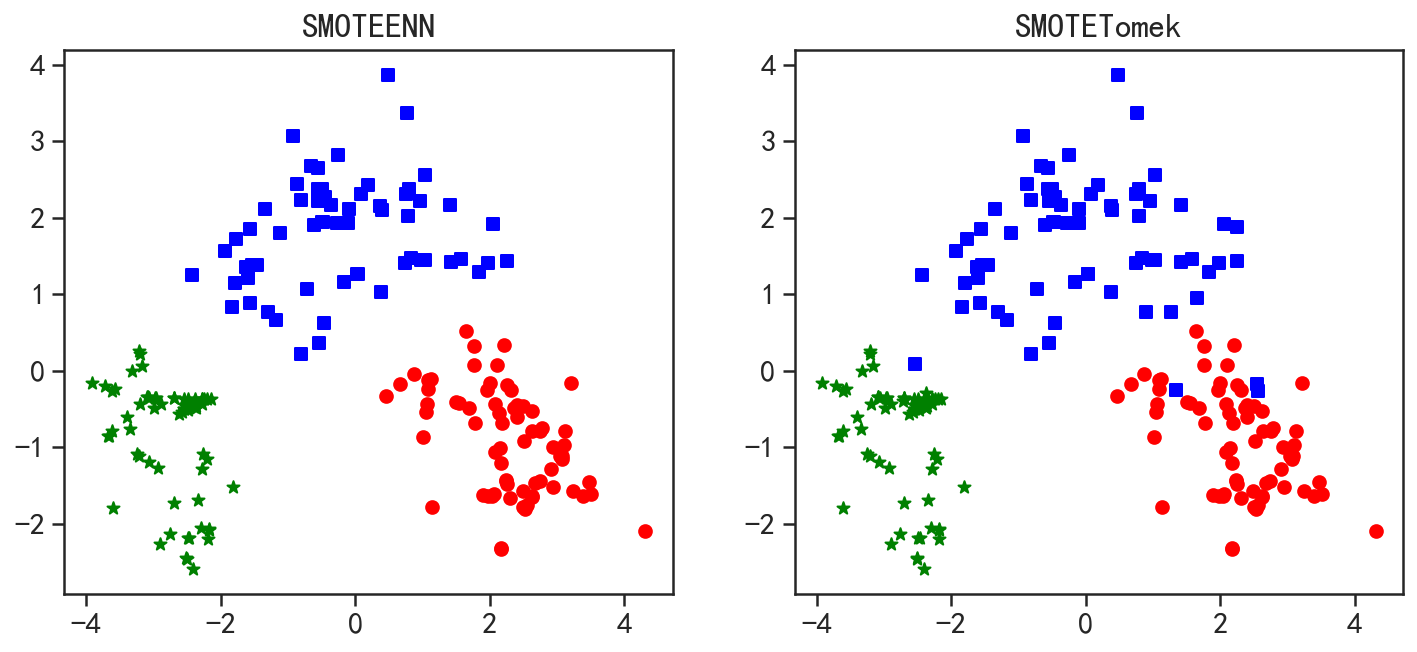

In [53]:
## 可视化不同算法下的数据可视化结果，使用二维散点图
colors = ["red","blue","green"]
shapes = ["o","s","*"]
fig = plt.figure(figsize=(12,5))
## 综合采样算法SMOTEENN
plt.subplot(1,2,1)
for ii,y in enumerate(smoteenn_y):
    plt.scatter(smoteenn_x[ii,0],smoteenn_x[ii,1],s = 40,
                c = colors[y],marker = shapes[y])
    plt.title("SMOTEENN")
## 综合采样算法SMOTETomek
plt.subplot(1,2,2)
for ii,y in enumerate(smoteet_y):
    plt.scatter(smoteet_x[ii,0],smoteet_x[ii,1],s = 40,
                c = colors[y],marker = shapes[y])
    plt.title("SMOTETomek")
plt.show()